# ETRI 2026 휴먼이해 AI — 수면 7지표 예측 (재현 노트북)

스마트폰·웨어러블 센서 라이프로그(전날 하루)로 **그날 밤 수면의 7개 이진 지표**를 예측한다.
- **Q1~Q3**(설문): 수면질/피로/스트레스 — 개인 전체기간 평균 대비 이진화
- **S1~S4**(Withings 수면센서): TST/SE/SOL/WASO의 NSF 가이드라인 준수 여부
- 평가지표: **Average(Macro) Log Loss** → 잘 보정된 확률 출력이 핵심
- train 450 / test 250, 피험자 10명, **train→test 시간적 분포 이동(temporal shift)** 존재

## 실행 방법
- 입력: `./data/` (대회 제공 `ch2026_metrics_train.csv`, `ch2026_submission_sample.csv`, `ch2025_data_items/*.parquet`)
- 출력: `./submission.csv`
- **원본 데이터만으로 처음부터 전체 파이프라인 학습/추론** (외부 산출물 불필요, 약 12분)

## 개발 환경
- OS: Windows-10 (26200) / Python 3.11.15
- numpy 2.4.6 · pandas 2.3.3 · scikit-learn 1.7.2 · lightgbm 4.6.0 · catboost 1.2.10 · torch 2.11.0+cu128 · transformers 4.57.6 · timm 1.0.27

## 사용한 공식 공개 사전학습 모델
- **SigLIP-Large** `google/siglip-large-patch16-256` (HuggingFace, **frozen 임베딩으로만** 사용 — 학습 안 함)
  - 출처: https://huggingface.co/google/siglip-large-patch16-256

## 전체 설계 한눈에
**[다중 소스] → [블렌딩] → [shift-aware 보정]** 의 3단 구조.
1. 서로 다른 관점의 **9개 베이스 소스**(트리/시퀀스DL/비전/수면재구성/이웃)를 만든다.
2. 타겟별 **greedy 블렌딩**으로 합친다.
3. 라벨 정의·시간이동에 맞춘 **잔차 보정**(daystate 라우팅 / pairwise 순위학습 / forward-CV)을 얹는다.

> 핵심 설계 철학: ① 모든 피처를 **피험자내 정규화**(개인 상대성), ② 소규모(N=450)에서 **분산 감소**(DL 다중 seed 평균), ③ test의 **시간이동을 인지한 검증**(forward-chaining CV).


In [1]:
# -*- coding: utf-8 -*-
"""ETRI 2026 수면 7지표 예측 — 단일 self-contained 솔루션 (원본 데이터 -> 제출).
1단계 백본: expbase(tree/prior/features/folds) + 4DL(DLens) + daystate + Neighbor
            + greedy 블렌드 + forward-CV(S1/S4 시간이동 재가중).
(이후 SigLIP/pairwise/SleepTree2 잔차를 추가하여 LB 0.5588 재현.)
"""
import os, re, time, glob, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.decomposition import NMF
from sklearn.metrics import log_loss
import torch, torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
DEV = "cuda" if torch.cuda.is_available() else "cpu"
t0 = time.time()

DATA = "data"; ITEMS = os.path.join(DATA, "ch2025_data_items")
LABELS = ["Q1","Q2","Q3","S1","S2","S3","S4"]; CLIP = (0.02, 0.98)
SF = {"mACStatus":"ch2025_mACStatus.parquet","mActivity":"ch2025_mActivity.parquet",
      "mAmbience":"ch2025_mAmbience.parquet","mBle":"ch2025_mBle.parquet","mGps":"ch2025_mGps.parquet",
      "mLight":"ch2025_mLight.parquet","mScreenStatus":"ch2025_mScreenStatus.parquet",
      "mUsageStats":"ch2025_mUsageStats.parquet","mWifi":"ch2025_mWifi.parquet",
      "wHr":"ch2025_wHr.parquet","wLight":"ch2025_wLight.parquet","wPedo":"ch2025_wPedo.parquet"}
AMB = ["Speech","Music","Silence","Television","Inside, small room","Vehicle","Snoring","Breathing"]

def C(a):
    """Clip probabilities to the competition-safe range."""
    return np.clip(a, *CLIP)


def lg(p):
    """Convert probabilities to logits after applying the shared clipping."""
    p = np.clip(np.asarray(p, float), *CLIP)
    return np.log(p / (1 - p))


def sg(z):
    """Numerically stable sigmoid used by downstream blend extensions."""
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

## 1) 센서 로딩 + 피처 (expbase.load/get_base) =====================

**[기법] 센서 피처 엔지니어링 (피험자내 정규화 + 시계열 파생)**
12개 센서 parquet을 (피험자, lifelog_date) 하루 단위로 집계한다.
- 시간대별 윈도우(all/day/eve/prebed/night/morning/deep) × 통계(mean/std/min/max/median/sum)
- **피험자내 시계열 파생**: lag(diff)·rolling(3)·EMA·expanding mean → "그 사람 평소 대비 오늘"을 인코딩 (Q 라벨이 '개인 평균 대비'라 직결)
- 야간 윈도우는 lifelog_date 기준으로 귀속(취침은 그날 저녁→다음날 새벽)

In [2]:
# ===================== 1) 센서 로딩 + 피처 (expbase.load/get_base) =====================
def load_sensor(name):
    """Load one raw sensor parquet and normalize it to subject/date/hour rows."""
    d = pd.read_parquet(os.path.join(ITEMS, SF[name]))
    ts = pd.to_datetime(d["timestamp"])
    o = pd.DataFrame({"subject_id": d["subject_id"].values})
    o["date"] = ts.dt.date.values
    o["hour"] = ts.dt.hour.values
    o["minute"] = ts.dt.minute.values
    if name == "wHr":
        # 심박: 생리적 유효범위(30~220bpm)만 남기고 분 단위 평균/최소/최대/표준편차 집계(이상치 제거)
        s = d["heart_rate"].apply(lambda x:(lambda a:(np.mean(a),np.min(a),np.max(a),np.std(a)) if len(a) else (np.nan,)*4)(np.asarray(x,float)[(np.asarray(x,float)>=30)&(np.asarray(x,float)<=220)]) if np.ndim(x) else (x,x,x,0))
        o["hr"]=[v[0] for v in s]; o["hr_min"]=[v[1] for v in s]; o["hr_max"]=[v[2] for v in s]; o["hr_sd"]=[v[3] for v in s]
    elif name == "wPedo":
        for c in ["step","distance","burned_calories","speed","step_frequency"]: o[c]=pd.to_numeric(d[c],errors="coerce").values
    elif name == "mACStatus": o["charge"]=pd.to_numeric(d["m_charging"],errors="coerce").values
    elif name == "mScreenStatus": o["screen"]=pd.to_numeric(d["m_screen_use"],errors="coerce").values
    elif name == "mActivity": o["activity"]=pd.to_numeric(d["m_activity"],errors="coerce").values
    elif name == "mLight": o["mlight"]=pd.to_numeric(d["m_light"],errors="coerce").values
    elif name == "wLight": o["wlight"]=pd.to_numeric(d["w_light"],errors="coerce").values
    elif name == "mAmbience":
        o["amb_top"]=d["m_ambience"].apply(lambda a: float(a[0][1]) if np.ndim(a) and len(a) else np.nan)
        for c in AMB: o[f"amb_{c}"]=d["m_ambience"].apply(lambda a,c=c: next((float(p[1]) for p in a if p[0]==c),0.0) if np.ndim(a) else 0.0)
    elif name == "mGps":
        o["gspd"]=d["m_gps"].apply(lambda a: np.nanmean([x["speed"] for x in a]) if np.ndim(a) and len(a) else np.nan)
        o["gdisp"]=d["m_gps"].apply(lambda a:(lambda la,lo:(np.nanmax(la)-np.nanmin(la))+(np.nanmax(lo)-np.nanmin(lo)) if len(la) else np.nan)([x["latitude"] for x in a],[x["longitude"] for x in a]) if np.ndim(a) and len(a) else np.nan)
    elif name == "mWifi": o["wifi_n"]=d["m_wifi"].apply(lambda a: len(a) if np.ndim(a) else np.nan)
    elif name == "mBle": o["ble_n"]=d["m_ble"].apply(lambda a: len(a) if np.ndim(a) else np.nan)
    elif name == "mUsageStats": o["use"]=d["m_usage_stats"].apply(lambda a: sum(float(x["total_time"]) for x in a) if np.ndim(a) else np.nan)
    m = o["hour"] < 10
    # 야간 윈도우(18시~다음날10시)는 '그 밤'으로 귀속: 새벽(0~10시) 기록은 전날 날짜로 당겨 수면이 하루에 묶이게 함
    o["night_date"] = np.where(o["hour"].isin(list(range(18,24))+list(range(0,10))),
                               np.where(m,(pd.to_datetime(o["date"])-pd.Timedelta(days=1)).dt.date, o["date"]), None)
    return o


def load_sensors():
    """Load all sensor sources used by the feature builders."""
    return {name: load_sensor(name) for name in SF}


print("센서 로딩...", flush=True)
SENSORS = load_sensors()
train = pd.read_csv(os.path.join(DATA,"ch2026_metrics_train.csv"))
test  = pd.read_csv(os.path.join(DATA,"ch2026_submission_sample.csv"))
for d in (train, test):
    d["lifelog_date"]=pd.to_datetime(d["lifelog_date"]).dt.date; d["sleep_date"]=pd.to_datetime(d["sleep_date"]).dt.date
DAYW={"all":range(0,24),"day":range(9,18),"eve":range(18,24),"prebed":range(21,24)}
NIGHTW={"night":range(0,7),"morning":range(6,10),"deep":range(0,4)}
STAT=["mean","std","min","max","median"]; SUM={"step","distance","burned_calories","use","gdisp"}
def agg(d,vc,key,win,wn):
    """Aggregate one sensor table over a named hour window."""
    s=d[d.hour.isin(list(win))]
    if s.empty: return None
    g=s.groupby(["subject_id",key])
    a=g[vc].agg(STAT)
    a.columns=[f"{c}_{wn}_{st}" for c in vc for st in STAT]
    sc=[c for c in vc if c in SUM]
    if sc: a=a.join(g[sc].sum().rename(columns={c:f"{c}_{wn}_sum" for c in sc}))
    return a.reset_index().rename(columns={key:"lifelog_date"})
parts=[]
for name in SF:
    d=SENSORS[name]; vc=[c for c in d.columns if c not in ("subject_id","date","hour","minute","night_date")]
    for wn,wh in DAYW.items():
        a=agg(d,vc,"date",wh,wn)
        if a is not None: parts.append(a.set_index(["subject_id","lifelog_date"]))
    dn=d.dropna(subset=["night_date"])
    for wn,wh in NIGHTW.items():
        a=agg(dn,vc,"night_date",wh,wn)
        if a is not None: parts.append(a.set_index(["subject_id","lifelog_date"]))
feat=pd.concat(parts,axis=1); feat=feat.loc[:,~feat.columns.duplicated()].reset_index()
feat["lifelog_date"]=pd.to_datetime(feat["lifelog_date"]).dt.date
feat.columns=[c if c in ("subject_id","lifelog_date") else re.sub(r"[^0-9A-Za-z_]+","_",str(c)).strip("_") for c in feat.columns]
base_cols=[c for c in feat.columns if c not in ("subject_id","lifelog_date")]
def attach(df):
    """Attach daily aggregate features and calendar covariates."""
    m=df.merge(feat,on=["subject_id","lifelog_date"],how="left")
    dt=pd.to_datetime(m["lifelog_date"])
    m["dow"]=dt.dt.dayofweek
    m["month"]=dt.dt.month
    m["is_weekend"]=(dt.dt.dayofweek>=5).astype(int)
    m["subject_num"]=m["subject_id"].str.replace("id","").astype(int)
    return m


def add_ts(m):
    """Add per-subject lag, rolling, EMA, and expanding features."""
    m=m.sort_values(["subject_id","lifelog_date"]).reset_index(drop=True)
    g=m.groupby("subject_id")
    nc={}
    for c in base_cols:                                                      # 피험자내 시계열 파생 = "그 사람 평소 대비 오늘"(Q라벨이 개인평균 대비라 직결)
        nc[c+"__d1"]=g[c].diff()                                             # 전날 대비 변화량(lag-1 diff)
        nc[c+"__r3"]=g[c].transform(lambda s:s.rolling(3,min_periods=1).mean())   # 최근 3일 이동평균(단기 추세)
        nc[c+"__ema"]=g[c].transform(lambda s:s.ewm(span=3,min_periods=1).mean()) # 지수가중 이동평균(최근 가중)
        nc[c+"__exp"]=g[c].transform(lambda s:s.expanding(min_periods=1).mean())  # 누적 평균(개인 기준선)
    return pd.concat([m,pd.DataFrame(nc,index=m.index)],axis=1)
train_f=add_ts(attach(train)); test_f=add_ts(attach(test))
FC=[c for c in train_f.columns if c not in ["subject_id","sleep_date","lifelog_date"]+LABELS]; y=train_f[LABELS].values
ntr=len(train_f); nte=len(test_f)
sid=train_f["subject_id"].astype(str).values; sid_te=test_f["subject_id"].astype(str).values
sd=pd.to_datetime(train_f["sleep_date"]).values; sd_te=pd.to_datetime(test_f["sleep_date"]).values

def folds_sh(df,n=5):
    """Subject-aware shuffled temporal folds used by all OOF sources."""
    d=df.sort_values(["subject_id","lifelog_date"]).reset_index(); blk=max(n*2,4); by={}
    for s,g in d.groupby("subject_id",sort=False): by[s]=[c for c in np.array_split(g["index"].to_numpy(),blk) if len(c)]  # 피험자별 날짜순을 시간블록으로 분할
    F=[]
    for f in range(n):
        v=[]
        for ch in by.values():
            for h in (f,f+n):                                                # 각 폴드가 피험자마다 앞·뒤 블록을 고루 검증(시간 누수 줄인 subject-aware 폴드)
                if h<len(ch): v.append(ch[h])
        v=np.concatenate(v); F.append((np.setdiff1d(d["index"].values,v),v))
    return F
folds=folds_sh(train_f,5)
def macro_ll(yy,p):
    p=C(p); return float(np.mean([log_loss(yy[:,i],p[:,i],labels=[0,1]) for i in range(7)]))
print(f"피처 완료 train{ntr} test{nte} FC{len(FC)} ({time.time()-t0:.0f}s)", flush=True)

센서 로딩...


피처 완료 train450 test250 FC5079 (52s)


## 1.5) 설계 동기 (EDA) — 원본 데이터가 말해주는 것

본격적인 모델링 전에, **데이터의 두 가지 사실**이 이후 핵심 설계를 결정한다.
- 그림A(시간이동) → **forward-CV**가 필요한 이유
- 그림B(피험자별 라벨편차) → **피험자내 정규화·pairwise(Q)** vs **prior(S)**를 가른 이유

In [3]:
# 한글 폰트 + 공통 설정 (이후 모든 그림 공통)
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager
_avail={f.name for f in font_manager.fontManager.ttflist}
for _f in ["Malgun Gothic","NanumGothic","Gulim","AppleGothic"]:
    if _f in _avail: matplotlib.rcParams["font.family"]=_f; break
matplotlib.rcParams["axes.unicode_minus"]=False

### 그림A. train→test 시간이동 (← forward-CV의 근거)
test의 sleep_date가 train보다 **뒤쪽 날짜**에 몰려 있다. 무작위 분할 CV는 이 이동을 못 본다 →
그래서 **앞 날짜로 학습→뒤 날짜로 검증**하는 forward-chaining CV로 S1/S4 가중치를 다시 고른다.

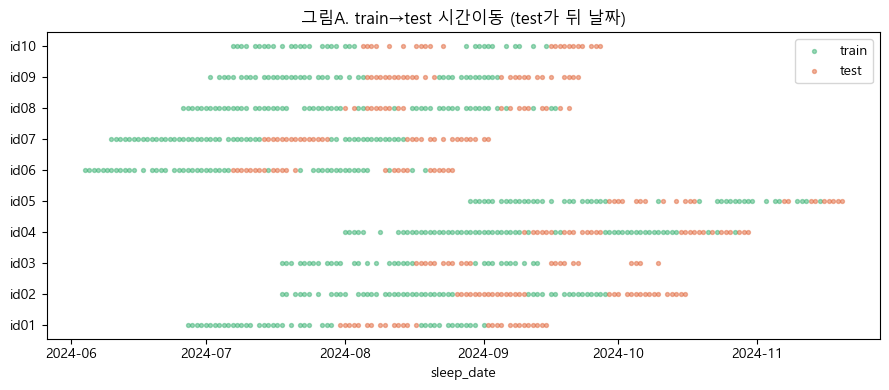

In [4]:
fig,ax=plt.subplots(figsize=(9,4))
subs=sorted(set(sid)|set(sid_te)); ymap={s:k for k,s in enumerate(subs)}
ax.scatter(pd.to_datetime(sd),[ymap[s] for s in sid],s=8,alpha=.5,label="train",color="#3bb273")
ax.scatter(pd.to_datetime(sd_te),[ymap[s] for s in sid_te],s=8,alpha=.5,label="test",color="#e1693e")
ax.set_yticks(range(len(subs))); ax.set_yticklabels(subs)
ax.set_xlabel("sleep_date"); ax.set_title("그림A. train→test 시간이동 (test가 뒤 날짜)"); ax.legend()
plt.tight_layout(); plt.show()

### 그림B. 피험자별 라벨 양성률 (← 정규화 vs prior의 근거)
**Q1~Q3**(설문)은 피험자마다 양성률 편차가 크다 → "개인 평균 대비"라는 정의에 맞춰 **피험자내 정규화·pairwise 순위학습**.
**S1~S4**(NSF 절대기준)은 피험자별 충족률이 비교적 안정적 → **prior(개인 기저율)**가 강한 앵커.

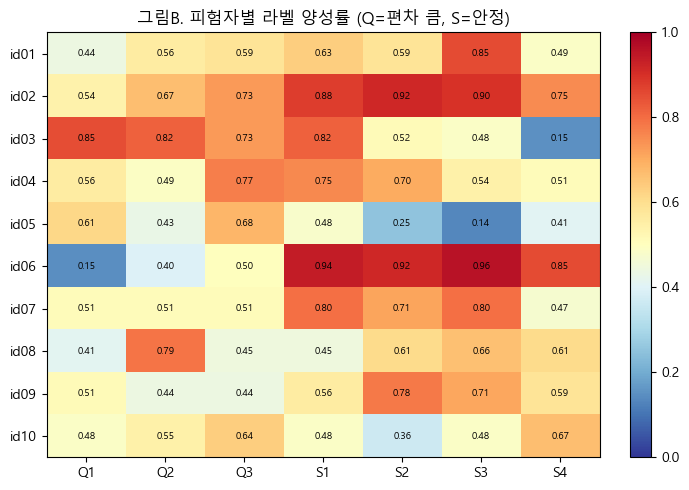

In [5]:
_df=pd.DataFrame(y,columns=LABELS); _df["sid"]=sid
rate=_df.groupby("sid")[LABELS].mean()
fig,ax=plt.subplots(figsize=(7,5))
im=ax.imshow(rate.values,aspect="auto",cmap="RdYlBu_r",vmin=0,vmax=1)
ax.set_xticks(range(7)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(len(rate))); ax.set_yticklabels(rate.index)
for a in range(len(rate)):
    for b in range(7): ax.text(b,a,f"{rate.values[a,b]:.2f}",ha="center",va="center",fontsize=7)
ax.set_title("그림B. 피험자별 라벨 양성률 (Q=편차 큼, S=안정)"); plt.colorbar(im,fraction=.04)
plt.tight_layout(); plt.show()

## 2) tree (LGBM+Cat+ET) + prior =====================

**[기법] 트리 앙상블 + Pseudo-labeling, 그리고 피험자 사전확률**
- **tree**: LightGBM + CatBoost + ExtraTrees 가중 평균(0.3/0.4/0.3). ExtraTrees 중요도로 상위 150피처 선택, 폴드 OOF.
  - Pseudo-labeling: 1차 예측 중 confident(≥0.85)한 test 행을 학습에 추가(준지도)로 소표본 보강.
- **prior**: 피험자별 라벨 평균(개인 기저율). 단순하지만 강력한 anchor — 특히 S 라벨(NSF 절대기준)은 개인별 충족률이 안정적이라 prior가 강한 베이스라인.

In [6]:
# ===================== 2) tree (LGBM+Cat+ET) + prior =====================
def imp_sel(Xa,ya,k=150):
    """Select stable tree features for one label."""
    et=ExtraTreesClassifier(n_estimators=120,max_depth=8,min_samples_leaf=5,n_jobs=-1,random_state=0)
    et.fit(Xa.fillna(0),ya)
    return pd.Series(et.feature_importances_,index=Xa.columns).sort_values(ascending=False).head(k).index.tolist()  # ExtraTrees 중요도 상위 k개만 선택(고차원 과적합 방지)


def train_tree_source(pl=None,thr=0.85):
    """Train the LGBM/CatBoost/ExtraTrees source, optionally with pseudo labels."""
    oof=np.zeros((ntr,7)); pred=np.zeros((nte,7))
    for j in range(7):
        yj=y[:,j]
        if pl is not None:                                  # Pseudo-labeling: 1차 예측이 확신(≥thr)한 test행을 학습에 추가(준지도, 소표본 보강)
            conf=np.maximum(pl[:,j],1-pl[:,j])              # 0/1 어느쪽이든 확신 정도
            mask=conf>=thr                                  # 확신 임계(0.85) 넘는 행만
            pX=test_f[FC][mask]
            pY=(pl[mask,j]>0.5).astype(int)                 # 의사라벨(하드 라벨)
        for tr,va in folds:
            a,b=train_f.iloc[tr],train_f.iloc[va]
            med=a[FC].median()
            Xa,Xb,Xt=a[FC].fillna(med),b[FC].fillna(med),test_f[FC].fillna(med)
            ytr=yj[tr]
            if pl is not None and mask.sum()>0:
                Xa=pd.concat([Xa,pX.fillna(med)])
                ytr=np.concatenate([ytr,pY])
            cols=imp_sel(Xa,ytr,150)
            sf=[f"f{i}" for i in range(len(cols))]
            Xtr=Xa[cols].copy(); Xtr.columns=sf
            Xva=Xb[cols].copy(); Xva.columns=sf
            Xte=Xt[cols].copy(); Xte.columns=sf
            lm=lgb.LGBMClassifier(objective="binary",n_estimators=250,learning_rate=0.03,num_leaves=7,min_child_samples=40,reg_lambda=5,colsample_bytree=.5,verbose=-1)
            lm.fit(Xtr,ytr)                                 # LightGBM(얕은 트리+강정규화, 소표본 과적합 억제)
            cm=CatBoostClassifier(iterations=250,learning_rate=0.03,depth=4,l2_leaf_reg=8,verbose=0,allow_writing_files=False)
            cm.fit(Xtr,ytr)                                 # CatBoost(다른 부스팅 관점)
            et=ExtraTreesClassifier(n_estimators=500,max_depth=7,min_samples_leaf=6,n_jobs=-1,random_state=0)
            et.fit(Xtr,ytr)                                 # ExtraTrees(배깅 관점, 분산 감소)
            oof[va,j]=.4*cm.predict_proba(Xva)[:,1]+.3*lm.predict_proba(Xva)[:,1]+.3*et.predict_proba(Xva)[:,1]   # 3모델 가중평균(Cat0.4/LGBM0.3/ET0.3)
            pred[:,j]+=(.4*cm.predict_proba(Xte)[:,1]+.3*lm.predict_proba(Xte)[:,1]+.3*et.predict_proba(Xte)[:,1])/len(folds)  # test는 폴드평균
    return C(oof),C(pred)
def prior_src():
    """Subject historical mean prior source."""
    po=np.zeros((ntr,7))
    for tr,va in folds:                                     # 누수 방지: 폴드 학습부분만으로 피험자 평균 산출
        a=train_f.iloc[tr]; sm=a.groupby("subject_id")[LABELS].mean(); gl=a[LABELS].mean()  # sm=피험자별 라벨 평균(개인 기저율), gl=전체 평균(폴백)
        for j,l in enumerate(LABELS): po[va,j]=train_f.iloc[va]["subject_id"].map(sm[l]).fillna(gl[l]).values  # 검증행에 그 피험자 기저율 매핑
    sm=train_f.groupby("subject_id")[LABELS].mean(); gl=train_f[LABELS].mean()
    pp=np.column_stack([test_f["subject_id"].map(sm[l]).fillna(gl[l]).values for l in LABELS])
    return C(po),C(pp)
print("tree(pseudo) 학습...", flush=True)
_,bp=train_tree_source(); tree_o,tree_p=train_tree_source(bp,0.85)
prior_o,prior_p=prior_src()
print(f"tree={macro_ll(y,tree_o):.4f} prior={macro_ll(y,prior_o):.4f} ({time.time()-t0:.0f}s)", flush=True)

tree(pseudo) 학습...


tree=0.6145 prior=0.6270 (203s)


## 3) 4DL (GRU/BiLSTM/TCN/Attn) + DLens(다중 seed 평균) =====================

**[기법] 시퀀스 딥러닝 4종 + DLens(다중 seed 평균 = 분산 감소)**
센서를 24시간×채널 시계열로 만들어 4개 작은 인코더로 학습:
- **GRU / BiLSTM / TCN / Attention** (각각 1D-CNN + 시퀀스 인코더 + 피험자 임베딩 + 멀티태스크 7헤드)
- **DLens**: 같은 모델을 **여러 random seed로 학습해 예측을 평균**한다. 신경망은 고분산 학습기라, N=450 소표본에서 seed 평균이 분산을 줄여 안정적으로 일반화한다(SWA식 아이디어). *이 대회에서 LB로 검증된 몇 안 되는 robust한 이득.*

In [7]:
# ===================== 3) 4DL (GRU/BiLSTM/TCN/Attn) + DLens(다중 seed 평균) =====================
# 6개 센서 채널을 시간(0~23시) × 채널 시계열로 만들어 작은 시퀀스 인코더 4종에 투입
NB=24; CH=[("wHr","hr"),("wPedo","step"),("mScreenStatus","screen"),("mACStatus","charge"),("mLight","mlight"),("mActivity","activity")]
def chan(name,col):
    """Build one hourly channel table for the neural sequence models."""
    d=SENSORS[name][["subject_id","date","hour",col]].dropna(subset=[col]).copy()
    return d.groupby(["subject_id","date","hour"])[col].mean().unstack("hour").reindex(columns=range(NB))
TAB={f"{n}_{c}":chan(n,c) for n,c in CH}
def tensor(df):
    """Convert hourly channel tables into C x 24 tensors."""
    keys=list(zip(df["subject_id"],df["lifelog_date"]))
    return np.stack([TAB[k].reindex(pd.MultiIndex.from_tuples(keys)).values.astype("float32") for k in TAB],1)
Xtr_dl=tensor(train_f); Xte_dl=tensor(test_f)
for c in range(Xtr_dl.shape[1]):
    mu,sdv=np.nanmean(Xtr_dl[:,c]),np.nanstd(Xtr_dl[:,c])+1e-6; Xtr_dl[:,c]=(Xtr_dl[:,c]-mu)/sdv; Xte_dl[:,c]=(Xte_dl[:,c]-mu)/sdv
Xtr_dl=np.nan_to_num(Xtr_dl); Xte_dl=np.nan_to_num(Xte_dl)
sj_tr=train_f["subject_num"].values-1; sj_te=test_f["subject_num"].values-1
nsub=int(max(sj_tr.max(),sj_te.max()))+1; Cc=Xtr_dl.shape[1]; L=7
class GRUNet(nn.Module):
    def __init__(s,emb=8,h=48,p=0.4):
        super().__init__(); s.cnn=nn.Sequential(nn.Conv1d(Cc,32,3,padding=1),nn.ReLU(),nn.BatchNorm1d(32),nn.Dropout(p),nn.Conv1d(32,32,3,padding=1),nn.ReLU()); s.r=nn.GRU(32,32,batch_first=True); s.e=nn.Embedding(nsub,emb); s.dp=nn.Dropout(p); s.head=nn.Sequential(nn.Linear(32+emb,h),nn.ReLU(),nn.BatchNorm1d(h),nn.Dropout(p),nn.Linear(h,L))
    def forward(s,x,sj): c=s.cnn(x).permute(0,2,1); o,_=s.r(c); return s.head(torch.cat([s.dp(o[:,-1,:]),s.e(sj)],1))
class LSTMNet(nn.Module):
    def __init__(s,emb=8,h=48,p=0.4):
        super().__init__(); s.cnn=nn.Sequential(nn.Conv1d(Cc,32,3,padding=1),nn.ReLU(),nn.BatchNorm1d(32),nn.Dropout(p),nn.Conv1d(32,32,3,padding=1),nn.ReLU()); s.r=nn.LSTM(32,32,batch_first=True,bidirectional=True); s.e=nn.Embedding(nsub,emb); s.dp=nn.Dropout(p); s.head=nn.Sequential(nn.Linear(64+emb,h),nn.ReLU(),nn.BatchNorm1d(h),nn.Dropout(p),nn.Linear(h,L))
    def forward(s,x,sj): c=s.cnn(x).permute(0,2,1); o,_=s.r(c); return s.head(torch.cat([s.dp(o[:,-1,:]),s.e(sj)],1))
class TCNNet(nn.Module):
    def __init__(s,emb=8,h=48,p=0.4):
        super().__init__(); s.t=nn.Sequential(nn.Conv1d(Cc,32,3,padding=1,dilation=1),nn.ReLU(),nn.BatchNorm1d(32),nn.Dropout(p),nn.Conv1d(32,32,3,padding=2,dilation=2),nn.ReLU(),nn.BatchNorm1d(32),nn.Dropout(p),nn.Conv1d(32,32,3,padding=4,dilation=4),nn.ReLU()); s.e=nn.Embedding(nsub,emb); s.dp=nn.Dropout(p); s.head=nn.Sequential(nn.Linear(32+emb,h),nn.ReLU(),nn.BatchNorm1d(h),nn.Dropout(p),nn.Linear(h,L))
    def forward(s,x,sj): c=s.t(x); g=c.mean(-1); return s.head(torch.cat([s.dp(g),s.e(sj)],1))
class AttnNet(nn.Module):
    def __init__(s,emb=8,h=48,p=0.4):
        super().__init__(); s.cnn=nn.Sequential(nn.Conv1d(Cc,32,3,padding=1),nn.ReLU(),nn.BatchNorm1d(32),nn.Dropout(p)); s.att=nn.MultiheadAttention(32,4,batch_first=True,dropout=p); s.e=nn.Embedding(nsub,emb); s.dp=nn.Dropout(p); s.head=nn.Sequential(nn.Linear(32+emb,h),nn.ReLU(),nn.BatchNorm1d(h),nn.Dropout(p),nn.Linear(h,L))
    def forward(s,x,sj): c=s.cnn(x).permute(0,2,1); a,_=s.att(c,c,c); g=a.mean(1); return s.head(torch.cat([s.dp(g),s.e(sj)],1))
ARCH={"GRU":GRUNet,"BiLSTM":LSTMNet,"TCN":TCNNet,"Attn":AttnNet}
def train_dl(Net,tr,va,seed):
    """Train one neural architecture on one fold and seed."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    net=Net().to(DEV)
    opt=torch.optim.AdamW(net.parameters(),lr=2e-3,weight_decay=1e-3)
    lf=nn.BCEWithLogitsLoss()
    Xt=torch.tensor(Xtr_dl).to(DEV)
    st=torch.tensor(sj_tr).long().to(DEV)
    yt=torch.tensor(y.astype("float32")).to(DEV)
    best=(9,None)
    for ep in range(250):
        net.train(); opt.zero_grad(); idx=np.random.permutation(tr); loss=lf(net(Xt[idx],st[idx]),yt[idx]); loss.backward(); opt.step()  # 멀티태스크 BCE(7헤드 동시학습)
        if ep%25==0:                                        # 25에폭마다 검증 logloss 확인 → 최적 체크포인트만 보관(조기종료 효과)
            net.eval()
            with torch.no_grad():
                pv=torch.sigmoid(net(Xt[va],st[va])).cpu().numpy()
            ll=np.mean([log_loss(y[va,k],np.clip(pv[:,k],0.02,0.98),labels=[0,1]) for k in range(L)])
            if ll<best[0]:
                best=(ll,{k:v.clone() for k,v in net.state_dict().items()})
    net.load_state_dict(best[1])
    net.eval()
    return net


def dl_oof(Net, seeds=(0,1,2,3,4,5,6,7)):
    """Create OOF/test predictions for one DL architecture using the 8-seed DLens."""
    oof=np.zeros((ntr,L))
    pred=np.zeros((nte,L))
    Xtet=torch.tensor(Xte_dl).to(DEV)
    ste=torch.tensor(sj_te).long().to(DEV)
    for tr,va in folds:
        for sdd in seeds:                                   # ★DLens: 같은 모델을 8개 random seed로 학습해 예측 평균 → 신경망 고분산을 줄여 안정화(SWA식, LB로 검증된 robust 이득)
            net=train_dl(Net,tr,va,sdd)
            with torch.no_grad():
                oof[va]+=torch.sigmoid(net(torch.tensor(Xtr_dl[va]).to(DEV),torch.tensor(sj_tr[va]).long().to(DEV))).cpu().numpy()/len(seeds)  # seed 평균
                pred+=torch.sigmoid(net(Xtet,ste)).cpu().numpy()/(len(folds)*len(seeds))  # test는 폴드×seed 평균
    return C(oof),C(pred)


def train_dl_sources():
    """Train GRU, BiLSTM, TCN, and attention sequence sources."""
    dl_oof_by_name={}
    dl_pred_by_name={}
    for nm,Net in ARCH.items():
        o,p=dl_oof(Net)
        dl_oof_by_name[nm]=o
        dl_pred_by_name[nm]=p
        print(f"DL {nm}={macro_ll(y,o):.4f} ({time.time()-t0:.0f}s)", flush=True)
    return dl_oof_by_name,dl_pred_by_name


DL_o,DL_p=train_dl_sources()

DL GRU=0.6238 (228s)


DL BiLSTM=0.6252 (253s)


DL TCN=0.6153 (274s)


DL Attn=0.6193 (298s)


## 4) daystate (transductive 30분 NMF 일상상태) =====================

**[기법] 비지도 일상상태 표현(daystate, transductive NMF)**
train+test 700일을 30분 bin × 6채널로 만들어 **NMF로 일상상태를 분해**(label-free, transductive). 점유율/전이/저녁 루틴/엔트로피 등을 피처화.
- 라벨을 안 쓰므로 test 분포까지 활용. 뒤의 **DSQ12 라우팅**과 **pairwise 피처**의 재료.

In [8]:
# ===================== 4) daystate (transductive 30분 NMF 일상상태) =====================
def build_daystate():
    """Build transductive 30-minute NMF day-state features for train and test days."""
    sid_all=np.r_[sid,sid_te]
    ld_all=pd.concat([pd.to_datetime(train_f["lifelog_date"]),pd.to_datetime(test_f["lifelog_date"])]).reset_index(drop=True)
    N=len(sid_all); Bn=48; Ch=6
    keys={(str(sid_all[i]),pd.Timestamp(ld_all[i]).normalize()):i for i in range(N)}
    sums=np.zeros((N,Bn,Ch)); cnts=np.zeros((N,Bn,Ch))
    def locate(s,t):
        t=pd.Timestamp(t); i=keys.get((str(s),t.normalize())); return i,(t.hour*60+t.minute)//30
    def raw(fn): return pd.read_parquet(os.path.join(ITEMS,fn))
    d=raw("ch2025_mAmbience.parquet")
    for s,t,a in zip(d.subject_id.values,d.timestamp.values,d.m_ambience.values):
        i,b=locate(s,t)
        if i is None: continue
        try:
            v=np.asarray([float(x[1]) for x in a if np.isfinite(float(x[1]))]); v=v[v>0]; v=v/v.sum(); x=-(v*np.log(v)).sum()
        except Exception: continue
        sums[i,b,0]+=x; cnts[i,b,0]+=1
    d=raw("ch2025_mGps.parquet")
    for s,t,a in zip(d.subject_id.values,d.timestamp.values,d.m_gps.values):
        i,b=locate(s,t)
        if i is None: continue
        try:
            sp=[float(x.get("speed",0) or 0) for x in a]; la=np.asarray([float(x["latitude"]) for x in a]); lo=np.asarray([float(x["longitude"]) for x in a])
            x=np.log1p(np.mean(np.maximum(sp,0))+100*np.sum(np.hypot(np.diff(la),np.diff(lo))))
        except Exception: continue
        sums[i,b,1]+=x; cnts[i,b,1]+=1
    for fn,col,k in [("ch2025_mActivity.parquet","m_activity",2),("ch2025_mScreenStatus.parquet","m_screen_use",3)]:
        d=raw(fn)
        for s,t,x in zip(d.subject_id.values,d.timestamp.values,d[col].values):
            i,b=locate(s,t)
            if i is None: continue
            try: x=float(x)
            except Exception: continue
            sums[i,b,k]+=x; cnts[i,b,k]+=1
    for fn,col,k in [("ch2025_mWifi.parquet","m_wifi",4),("ch2025_mBle.parquet","m_ble",5)]:
        d=raw(fn)
        for s,t,a in zip(d.subject_id.values,d.timestamp.values,d[col].values):
            i,b=locate(s,t)
            if i is None: continue
            try: x=np.log1p(len(a))
            except Exception: x=0.
            sums[i,b,k]+=x; cnts[i,b,k]+=1
    X=np.divide(sums,cnts,out=np.full_like(sums,np.nan),where=cnts>0)
    flat=X.reshape(N*Bn,Ch); trmask=np.repeat(np.arange(N)<ntr,Bn)
    med=np.nanmedian(flat[trmask],0); med=np.where(np.isfinite(med),med,0.)
    q1=np.nanpercentile(flat[trmask],25,axis=0); q3=np.nanpercentile(flat[trmask],75,axis=0)
    scale=np.where(np.isfinite(q3-q1)&((q3-q1)>1e-8),q3-q1,1.)
    ii=np.where(~np.isfinite(flat)); flat[ii]=np.take(med,ii[1]); Z=np.maximum((flat-med)/scale+2.,0.)
    # ★transductive NMF: train+test 700일 전체를 8개 잠재 '일상상태'로 비지도 분해(라벨 미사용 → test 분포까지 활용)
    nmf=NMF(n_components=8,init="random",random_state=2025,max_iter=400,alpha_W=.03,alpha_H=.03,l1_ratio=.1)
    W=nmf.fit_transform(Z).reshape(N,Bn,8); post=W/(W.sum(2,keepdims=True)+1e-12); state=post.argmax(2); occ=post.mean(1)  # state=30분bin별 우세상태, occ=하루 상태 점유율
    trans=(state[:,1:]!=state[:,:-1]).sum(1)[:,None].astype(float); ent=(-(occ*np.log(occ+1e-12)).sum(1))[:,None]
    active=(state!=state[:,0,None]); first=np.where(active.any(1),active.argmax(1),Bn)[:,None]/Bn
    last=(Bn-1-np.flip(active,1).argmax(1))[:,None]/Bn
    eve=state[:,36:48]; eve_run=np.ones((N,1))
    for i in range(N):
        bst=run=1
        for jj in range(1,12):
            run=run+1 if eve[i,jj]==eve[i,jj-1] else 1; bst=max(bst,run)
        eve_run[i,0]=bst/12.
    routine=np.zeros((N,1))
    for s in np.unique(sid_all):
        ix=np.where(sid_all==s)[0]; mu=occ[ix].mean(0); routine[ix,0]=np.abs(occ[ix]-mu).mean(1)
    rawf=np.hstack([occ,trans,first,last,eve_run,routine,ent]); z=np.zeros_like(rawf)
    for s in np.unique(sid_all):
        ix=np.where(sid_all==s)[0]; mu=rawf[ix].mean(0); sdv=rawf[ix].std(0); sdv=np.where(sdv>1e-8,sdv,1.); z[ix]=(rawf[ix]-mu)/sdv
    return np.nan_to_num(np.hstack([rawf,z]),nan=0.,posinf=0.,neginf=0.)
print("daystate NMF...", flush=True)
DS=build_daystate()  # (700, D)
# daystate를 소스로: 피처에 붙여 LGBM OOF/pred
DStr=DS[:ntr]; DSte=DS[ntr:]
def ds_source():
    """Train the LGBM source that consumes base features plus day-state features."""
    P=dict(n_estimators=300,learning_rate=0.02,num_leaves=15,min_child_samples=25,subsample=0.8,colsample_bytree=0.6,reg_lambda=5,verbose=-1,n_jobs=-1)
    Xall_tr=np.hstack([np.nan_to_num(train_f[FC].values),DStr]); Xall_te=np.hstack([np.nan_to_num(test_f[FC].values),DSte])
    eo=np.zeros((ntr,7)); ep=np.zeros((nte,7))
    for j in range(7):
        for tr,va in folds:
            m=lgb.LGBMClassifier(**P); m.fit(Xall_tr[tr],y[tr,j]); eo[va,j]=m.predict_proba(Xall_tr[va])[:,1]
        mf=lgb.LGBMClassifier(**P); mf.fit(Xall_tr,y[:,j]); ep[:,j]=mf.predict_proba(Xall_te)[:,1]
    return C(eo),C(ep)
ds_o,ds_p=ds_source()
print(f"daystate-src={macro_ll(y,ds_o):.4f} ({time.time()-t0:.0f}s)", flush=True)

daystate NMF...


daystate-src=0.6290 (354s)


## 4.5) SigLIP_L (siglip-large frozen 임베딩 -> LGBM) =====================

**[기법] 비전 파운데이션 모델(SigLIP-Large) frozen 임베딩**
센서 시계열을 2D 이미지로 만들어 사전학습 **SigLIP-Large** 비전 트랜스포머에 통과 → frozen pooler 임베딩 추출 → LGBM.
- 모델 가중치는 **학습하지 않음(frozen)** — 일반 시각 표현으로 센서 패턴을 다른 각도에서 인코딩(모달 다양성).
- 공식 공개 모델(HuggingFace), 재현 시 자동 다운로드.

In [9]:
# ===================== 4.5) SigLIP_L (siglip-large frozen 임베딩 -> LGBM) =====================
def siglip_source():
    """Extract frozen SigLIP-Large embeddings and train an LGBM source on them."""
    import torch.nn.functional as Ft
    from transformers import SiglipVisionModel
    CHs=[("wHr","hr"),("wHr","hr_min"),("wHr","hr_max"),("wHr","hr_sd"),("wPedo","step"),("wPedo","distance"),("mScreenStatus","screen"),("mACStatus","charge"),("mLight","mlight"),("wLight","wlight"),("mActivity","activity"),("mGps","gspd")]
    def chan2(name,col):
        d=SENSORS[name]
        if col not in d.columns: return None
        s=d[["subject_id","date","hour",col]].dropna(subset=[col]); return s.groupby(["subject_id","date","hour"])[col].mean().unstack("hour").reindex(columns=range(NB))
    TAB2=[(f"{n}_{c}",chan2(n,c)) for n,c in CHs]; TAB2=[(k,v) for k,v in TAB2 if v is not None]
    def imgtensor(df):
        keys=list(zip(df["subject_id"],df["lifelog_date"])); return np.stack([w.reindex(pd.MultiIndex.from_tuples(keys)).values.astype("float32") for k,w in TAB2],1)
    Xi=imgtensor(train_f); Xj=imgtensor(test_f)
    for c in range(Xi.shape[1]):
        mu,sv=np.nanmean(Xi[:,c]),np.nanstd(Xi[:,c])+1e-6; Xi[:,c]=(Xi[:,c]-mu)/sv; Xj[:,c]=(Xj[:,c]-mu)/sv
    Xi=np.nan_to_num(Xi); Xj=np.nan_to_num(Xj)
    def to_img(x,size):
        # 센서 시계열을 2D 이미지(256x256, 3채널)로 변환 → 비전모델 입력 형태로
        t=torch.tensor(x).unsqueeze(1); t=Ft.interpolate(t,size=(size,size),mode="bilinear",align_corners=False); return t.repeat(1,3,1,1)
    MODEL="google/siglip-large-patch16-256"; SZ=256        # 공식 공개 사전학습 비전 트랜스포머(HuggingFace, 자동 다운로드)
    vm=SiglipVisionModel.from_pretrained(MODEL).to(DEV).eval()
    for p in vm.parameters(): p.requires_grad=False         # ★frozen: 가중치 학습 안 함 — 일반 시각표현으로 센서패턴을 다른 각도로 인코딩(모달 다양성)
    def emb(X):
        out=[]; im=to_img(X,SZ)
        with torch.no_grad():
            for i in range(0,len(im),16):
                b=im[i:i+16].to(DEV); e=vm(pixel_values=b).pooler_output.float().cpu().numpy(); out.append(e)  # frozen pooler 임베딩 추출(이후 LGBM 입력)
        return np.concatenate(out)
    Etr=emb(Xi); Ete=emb(Xj)
    Etr=pd.DataFrame(Etr,columns=[f"e{i}" for i in range(Etr.shape[1])]); Ete=pd.DataFrame(Ete,columns=Etr.columns)
    eo=np.zeros((ntr,7)); ep=np.zeros((nte,7))
    for j in range(7):
        for tr,va in folds:
            m=lgb.LGBMClassifier(objective="binary",n_estimators=200,learning_rate=0.03,num_leaves=15,min_child_samples=20,reg_lambda=3,colsample_bytree=.4,verbose=-1)
            m.fit(Etr.iloc[tr],y[tr,j]); eo[va,j]=m.predict_proba(Etr.iloc[va])[:,1]; ep[:,j]+=m.predict_proba(Ete)[:,1]/len(folds)
    return C(eo),C(ep)
print("SigLIP-large 임베딩 추출...", flush=True)
sg_o,sg_p=siglip_source()
print(f"SigLIP_L={macro_ll(y,sg_o):.4f} ({time.time()-t0:.0f}s)", flush=True)

SigLIP-large 임베딩 추출...


SigLIP_L=0.6951 (367s)


## 4.6) SleepTree2 (수면재구성 v2 + tree_pseudo) =====================

**[기법] 트리 앙상블 + Pseudo-labeling, 그리고 피험자 사전확률**
- **tree**: LightGBM + CatBoost + ExtraTrees 가중 평균(0.3/0.4/0.3). ExtraTrees 중요도로 상위 150피처 선택, 폴드 OOF.
  - Pseudo-labeling: 1차 예측 중 confident(≥0.85)한 test 행을 학습에 추가(준지도)로 소표본 보강.
- **prior**: 피험자별 라벨 평균(개인 기저율). 단순하지만 강력한 anchor — 특히 S 라벨(NSF 절대기준)은 개인별 충족률이 안정적이라 prior가 강한 베이스라인.

In [10]:
# ===================== 4.6) SleepTree2 (수면재구성 v2 + tree_pseudo) =====================
def sleeptree2_source():
    """Reconstruct sleep-window features and train the extended tree source."""
    def night_series():
        hr=pd.read_parquet(f"{ITEMS}/ch2025_wHr.parquet"); ts=pd.to_datetime(hr["timestamp"])
        hr=pd.DataFrame({"subject_id":hr["subject_id"].values,"ts":ts.values,"hr":hr["heart_rate"].apply(lambda x:(lambda a:np.mean(a) if len(a) else np.nan)(np.asarray(x,float)[(np.asarray(x,float)>=30)&(np.asarray(x,float)<=220)]) if np.ndim(x) else x).values})
        pe=pd.read_parquet(f"{ITEMS}/ch2025_wPedo.parquet"); pt=pd.to_datetime(pe["timestamp"])
        pe=pd.DataFrame({"subject_id":pe["subject_id"].values,"ts":pt.values,"step":pd.to_numeric(pe["step"],errors="coerce").values})
        ac=pd.read_parquet(f"{ITEMS}/ch2025_mACStatus.parquet"); at=pd.to_datetime(ac["timestamp"])
        ac=pd.DataFrame({"subject_id":ac["subject_id"].values,"ts":at.values,"charge":pd.to_numeric(ac["m_charging"],errors="coerce").values})
        def asn(df):
            t=pd.to_datetime(df["ts"]); h=t.dt.hour; sdd=np.where(h>=18,(t+pd.Timedelta(days=1)).dt.date,np.where(h<12,t.dt.date,None))
            df=df.copy(); df["sleep_date"]=sdd; df["min"]=np.where(h>=18,(h-18)*60+t.dt.minute,(h+6)*60+t.dt.minute); return df.dropna(subset=["sleep_date"])
        return asn(hr),asn(pe),asn(ac)
    def longest_block(mask):
        best=(0,0,0); s=None
        for i,v in enumerate(list(mask)+[False]):
            if v and s is None: s=i
            elif not v and s is not None:
                if i-s>best[0]: best=(i-s,s,i); s=None
        return best
    hr,pe,ac=night_series(); Nn2=1080
    pg=dict(tuple(pe.groupby(["subject_id","sleep_date"]))); ag=dict(tuple(ac.groupby(["subject_id","sleep_date"]))); rows=[]
    for (s2,sdd),g in hr.groupby(["subject_id","sleep_date"]):
        H=np.full(Nn2,np.nan); ST=np.full(Nn2,np.nan); CHm=np.zeros(Nn2)
        for m,v in zip(g["min"].values.astype(int),g["hr"].values):
            if 0<=m<Nn2: H[m]=v
        if (s2,sdd) in pg:
            for m,v in zip(pg[(s2,sdd)]["min"].values.astype(int),pg[(s2,sdd)]["step"].values):
                if 0<=m<Nn2: ST[m]=v
        if (s2,sdd) in ag:
            for m,v in zip(ag[(s2,sdd)]["min"].values.astype(int),ag[(s2,sdd)]["charge"].values):
                if 0<=m<Nn2: CHm[m]=0 if np.isnan(v) else v
        Hs=pd.Series(H).interpolate(limit_area="inside").values; worn=~np.isnan(Hs)   # 심박 연속 = 워치 착용 구간
        row={"subject_id":s2,"sleep_date":sdd}
        if worn.sum()<60: rows.append(row); continue
        STf=pd.Series(ST).fillna(0).values; rest=(STf<=1)&worn                         # 걸음 거의 없음 = 안정(휴식) 구간 후보
        rests=pd.Series(rest.astype(float)).rolling(11,center=True,min_periods=1).mean().values>0.5  # 평활화로 노이즈 제거
        ln,s,e=longest_block(rests)                                                    # 가장 긴 휴식 블록 = 주수면 후보 구간
        if ln<30: rows.append(row); continue
        seg=np.zeros(Nn2,bool); seg[s:e]=True; thr=np.nanpercentile(Hs[worn],50)
        asleep=seg&(Hs<thr+5); asleep=pd.Series(asleep.astype(float)).rolling(7,center=True,min_periods=1).mean().values>0.4
        idx=np.where(asleep)[0]
        if len(idx)<20: rows.append(row); continue
        onset,wake=idx[0],idx[-1]; tib_s=s; ci=np.where(CHm>0)[0]
        if len(ci) and ci[0]<onset: tib_s=ci[0]
        TIB=wake-tib_s+1; TST=asleep[tib_s:wake+1].sum()    # TIB=잠자리시간, TST=실제수면시간(분)
        row["tst_min"]=TST; row["tib_min"]=TIB; row["se"]=TST/max(TIB,1); row["sol_min"]=onset-tib_s  # SE=수면효율, SOL=입면지연
        row["waso_min"]=(wake-onset+1)-asleep[onset:wake+1].sum(); row["sleep_hr"]=np.nanmean(Hs[asleep])  # WASO=중도각성, 수면중 평균심박
        row["n_awak"]=int(np.sum(np.diff(asleep.astype(int))==-1)); row["onset_min"]=onset; row["wake_min"]=wake
        row["worn_frac"]=worn.mean(); row["rest_len"]=ln
        row["nsf_tst"]=int(TST>=420); row["nsf_se"]=int(row["se"]>=0.85); row["nsf_sol"]=int(row["sol_min"]<=30); row["nsf_waso"]=int(row["waso_min"]<=20)  # NSF 가이드라인 충족 플래그(S1~S4 직접 겨냥 피처)
        rows.append(row)
    SFr=pd.DataFrame(rows); SFr["sleep_date"]=pd.to_datetime(SFr["sleep_date"]).dt.date
    sc=[c for c in SFr.columns if c not in ("subject_id","sleep_date")]
    trf2=train_f.merge(SFr,on=["subject_id","sleep_date"],how="left"); tef2=test_f.merge(SFr,on=["subject_id","sleep_date"],how="left")
    FC2=FC+sc
    # tree_pseudo on extended features (treeA 재사용, FC2로)
    def treeA2(tf,ef,fcs,pl=None,thr=0.85):
        oof=np.zeros((ntr,7)); pred=np.zeros((nte,7))
        for j in range(7):
            yj=y[:,j]
            if pl is not None: conf=np.maximum(pl[:,j],1-pl[:,j]); mask=conf>=thr; pX=ef[fcs][mask]; pY=(pl[mask,j]>0.5).astype(int)
            for tr,va in folds:
                a,b=tf.iloc[tr],tf.iloc[va]; med=a[fcs].median()
                Xa,Xb,Xt=a[fcs].fillna(med),b[fcs].fillna(med),ef[fcs].fillna(med); ytr=yj[tr]
                if pl is not None and mask.sum()>0: Xa=pd.concat([Xa,pX.fillna(med)]); ytr=np.concatenate([ytr,pY])
                cols=imp_sel(Xa,ytr,150); sf2=[f"f{i}" for i in range(len(cols))]
                Xtr=Xa[cols].copy();Xtr.columns=sf2;Xva=Xb[cols].copy();Xva.columns=sf2;Xte=Xt[cols].copy();Xte.columns=sf2
                lm=lgb.LGBMClassifier(objective="binary",n_estimators=250,learning_rate=0.03,num_leaves=7,min_child_samples=40,reg_lambda=5,colsample_bytree=.5,verbose=-1); lm.fit(Xtr,ytr)
                cm=CatBoostClassifier(iterations=250,learning_rate=0.03,depth=4,l2_leaf_reg=8,verbose=0,allow_writing_files=False); cm.fit(Xtr,ytr)
                et=ExtraTreesClassifier(n_estimators=500,max_depth=7,min_samples_leaf=6,n_jobs=-1,random_state=0); et.fit(Xtr,ytr)
                oof[va,j]=.4*cm.predict_proba(Xva)[:,1]+.3*lm.predict_proba(Xva)[:,1]+.3*et.predict_proba(Xva)[:,1]
                pred[:,j]+=(.4*cm.predict_proba(Xte)[:,1]+.3*lm.predict_proba(Xte)[:,1]+.3*et.predict_proba(Xte)[:,1])/len(folds)
        return C(oof),C(pred)
    _,bp2=treeA2(trf2,tef2,FC2); return treeA2(trf2,tef2,FC2,bp2,0.85)
print("SleepTree2 (수면재구성)...", flush=True)
st2_o,st2_p=sleeptree2_source()
print(f"SleepTree2={macro_ll(y,st2_o):.4f} ({time.time()-t0:.0f}s)", flush=True)

SleepTree2 (수면재구성)...


SleepTree2=0.6150 (518s)


## 5) Neighbor (날짜인접 라벨 가중) =====================

**[기법] 날짜인접 라벨 가중(Neighbor)**
같은 피험자의 **날짜가 가까운 다른 날 라벨**을 지수가중 평균. (OOF는 leave-one-out으로 누수 차단)
- 수면 지표의 날짜 자기상관을 직접 활용하는 단순·강건한 소스.

In [11]:
# ===================== 5) Neighbor (날짜인접 라벨 가중) =====================
def gp(a,b): return np.abs((a-b)/np.timedelta64(1,"D")).astype(float)


def neighbor_source():
    """Date-neighbor weighted subject history source."""
    neighbor_oof=np.zeros((ntr,7))
    neighbor_pred=np.zeros((nte,7))
    for s in np.unique(sid):
        ix=np.where(sid==s)[0]
        for i in ix:
            m=ix[ix!=i]                                     # leave-one-out: 자기 자신 제외(라벨 누수 차단)
            w=np.exp(-gp(sd[i],sd[m])/3)                    # 날짜가 가까울수록 큰 가중(지수감쇠, 스케일 3일)
            for j in range(7):
                neighbor_oof[i,j]=np.sum(w*y[m,j])/w.sum()  # 같은 피험자 인접날짜 라벨의 가중평균(수면지표 날짜 자기상관 활용)
    for i in range(nte):
        m=np.where(sid==sid_te[i])[0]
        w=np.exp(-gp(sd_te[i],sd[m])/3)
        for j in range(7):
            neighbor_pred[i,j]=np.sum(w*y[m,j])/w.sum()
    return C(neighbor_oof),C(neighbor_pred)


nb_o,nb_p=neighbor_source()

## 6) greedy 블렌드 (7소스) =====================

**[기법] 타겟별 greedy 블렌딩 + forward-CV S1/S4 재가중 (★핵심 개선)**
- **greedy coordinate-descent**: 타겟마다 prior에서 출발해 소스 가중치를 0.05/0.1씩 조정하며 logloss 최소화.
- **forward-chaining CV (shift-aware)**: test가 시간적으로 이동(뒤 날짜)했는데, 일반 random-fold CV로 고른 가중치는 일반화가 나쁘다. **앞 날짜로 학습→뒤 날짜 검증**하는 forward 폴드로 **S1/S4 가중치를 다시 선택**하면 held-out 최신 블록에서 일관 개선된다.
  - *본 솔루션의 가장 큰 LB 개선 레버. "random-OOF는 시간이동을 못 본다"를 정면으로 교정.*

In [12]:
# ===================== 6) greedy 블렌드 (7소스) =====================
# 진짜 best 9소스: tree/prior/4DL/SigLIP_L/SleepTree2/Neighbor
src_oof={"tree":tree_o,"prior":prior_o,"GRU":DL_o["GRU"],"BiLSTM":DL_o["BiLSTM"],"TCN":DL_o["TCN"],"Attn":DL_o["Attn"],"SigLIP":sg_o,"SleepTree2":st2_o,"Neighbor":nb_o}
src_pred={"tree":tree_p,"prior":prior_p,"GRU":DL_p["GRU"],"BiLSTM":DL_p["BiLSTM"],"TCN":DL_p["TCN"],"Attn":DL_p["Attn"],"SigLIP":sg_p,"SleepTree2":st2_p,"Neighbor":nb_p}
# 타겟별 소스셋: Q1/Q2(0,1)는 daystate 라우팅(DSQ12) 포함, 나머지는 9소스
source_names=list(src_oof)
oof_list9=[src_oof[k] for k in source_names]
pred_list9=[src_pred[k] for k in source_names]
oof_list_q12=oof_list9+[ds_o]
pred_list_q12=pred_list9+[ds_p]   # Q1/Q2용 = 9소스 + daystate
prior_source_index=source_names.index("prior")


def greedy_weights_for_label(oof_list, foldgen, j):
    """Coordinate-search blend weights for one label and fold generator."""
    num_sources=len(oof_list)
    greedy_weights=np.zeros(num_sources)
    greedy_weights[prior_source_index]=1.0                  # prior(개인 기저율)에서 출발 = 강건한 앵커
    for tr,va in foldgen:
        cur=log_loss(y[tr,j],C(sum(greedy_weights[i]*oof_list[i][tr,j] for i in range(num_sources))),labels=[0,1])
        for _ in range(40):                                 # coordinate-descent: 소스 가중치를 ±0.05/0.1씩 바꿔가며 logloss 최소화
            bb=(cur,None)
            for i in range(num_sources):
                for dd in (.1,-.1,.05,-.05):
                    w2=greedy_weights.copy()
                    w2[i]=max(0,w2[i]+dd)                   # 음수 금지 후 합=1로 정규화
                    ss=w2.sum()
                    if ss==0: continue
                    w2/=ss
                    ll=log_loss(y[tr,j],C(sum(w2[k]*oof_list[k][tr,j] for k in range(num_sources))),labels=[0,1])
                    if ll<bb[0]: bb=(ll,w2)
            if bb[1] is None: break
            greedy_weights,cur=bb[1],bb[0]
    return greedy_weights


def source_set_for_label(j):
    """Use the daystate source only for Q1/Q2 routing."""
    return (oof_list_q12,pred_list_q12) if j in (0,1) else (oof_list9,pred_list9)


def greedy_w(foldgen,j):
    oof_list,_=source_set_for_label(j)
    return greedy_weights_for_label(oof_list,foldgen,j)
# random-fold 가중치(기준) + forward-CV 가중치(S1/S4용)
allidx=np.arange(ntr); rng=np.random.RandomState(1); perm=rng.permutation(allidx)
rand_folds=[(np.concatenate([perm[:i*ntr//5],perm[(i+1)*ntr//5:]]),perm[i*ntr//5:(i+1)*ntr//5]) for i in range(5)]  # 일반 무작위 5폴드(기준 가중치용)
rs=allidx[np.argsort(sd)]                                   # 날짜순 정렬
# ★forward-chaining CV: 앞 날짜로 학습→뒤 날짜로 검증(test의 시간이동을 모사). 시작점 0.5~0.8을 미끄러뜨리며 4폴드
forward_folds=[(rs[:int(ntr*f)],rs[int(ntr*f):int(ntr*min(f+0.2,1.0))]) for f in [0.5,0.6,0.7,0.8]]


def blend_and_forward_cv():
    """Blend all sources, then replace S1/S4 weights with forward-chaining CV weights."""
    blend_pred=np.zeros((nte,7))
    blend_oof_local=np.zeros((ntr,7))
    for j in range(7):                                      # 먼저 7개 타겟 모두 random-fold greedy 가중치로 블렌드
        oof_list,pred_list=source_set_for_label(j)
        num_sources=len(oof_list)
        # OOF (점수확인용)
        for tr,va in rand_folds:
            greedy_weights=greedy_weights_for_label(oof_list,[(tr,va)],j)
            blend_oof_local[va,j]=C(sum(greedy_weights[i]*oof_list[i][va,j] for i in range(num_sources)))
        greedy_weights=greedy_weights_for_label(oof_list,rand_folds,j)
        blend_pred[:,j]=C(sum(greedy_weights[i]*pred_list[i][:,j] for i in range(num_sources)))
    # forward-CV S1/S4 재가중을 blend에 강도 1.0(full) 적용 = 100% forward 가중치
    for j in [3,6]:
        oof_list,pred_list=source_set_for_label(j)
        num_sources=len(oof_list)
        forward_weights=greedy_weights_for_label(oof_list,forward_folds,j)   # forward-chaining CV 가중치
        blend_pred[:,j]=C(sum(forward_weights[i]*pred_list[i][:,j] for i in range(num_sources)))   # strength 1.0
    return blend_pred,blend_oof_local


blend,blend_oof=blend_and_forward_cv()

print(f"[백본 블렌드 OOF macro = {macro_ll(y, blend_oof):.5f}]  ({time.time()-t0:.0f}s)", flush=True)

[백본 블렌드 OOF macro = 0.58431]  (532s)


## 6.5) feat_bank(M) + 피처모듈 + pairwise Q1/Q2 잔차 =====================

**[기법] 센서 피처 엔지니어링 (피험자내 정규화 + 시계열 파생)**
12개 센서 parquet을 (피험자, lifelog_date) 하루 단위로 집계한다.
- 시간대별 윈도우(all/day/eve/prebed/night/morning/deep) × 통계(mean/std/min/max/median/sum)
- **피험자내 시계열 파생**: lag(diff)·rolling(3)·EMA·expanding mean → "그 사람 평소 대비 오늘"을 인코딩 (Q 라벨이 '개인 평균 대비'라 직결)
- 야간 윈도우는 lifelog_date 기준으로 귀속(취침은 그날 저녁→다음날 새벽)

In [13]:
# ===================== 6.5) feat_bank(M) + 피처모듈 + pairwise Q1/Q2 잔차 =====================
# --- 기존 피처 모듈들을 그대로 임베드 (build(ctx) 패턴) ---
_MOD_SRC = {}
_MOD_SRC['daystate'] = 'def build(ctx):\n    """Label-free, transductive 30-minute daily-state representation."""\n    np, pd = ctx[\'np\'], ctx[\'pd\']\n    sid, ld, ntr = ctx[\'sid\'], ctx[\'ld\'], ctx[\'ntr\']\n    N, B, C = len(sid), 48, 6\n    keys = {(str(sid[i]), pd.Timestamp(ld[i]).normalize()): i for i in range(N)}\n    sums = np.zeros((N, B, C), float)\n    cnts = np.zeros((N, B, C), float)\n\n    def locate(s, t):\n        t = pd.Timestamp(t); i = keys.get((str(s), t.normalize()))\n        return i, (t.hour * 60 + t.minute) // 30\n\n    # ambience: entropy, a robust scalar summary of the acoustic scene\n    d = ctx[\'load\'](\'ch2025_mAmbience.parquet\')\n    for s, t, a in zip(d.subject_id.values, d.timestamp.values, d.m_ambience.values):\n        i, b = locate(s, t)\n        if i is None: continue\n        try:\n            v = np.asarray([float(x[1]) for x in a if np.isfinite(float(x[1]))])\n            v = v[v > 0]; v = v / v.sum(); x = -(v * np.log(v)).sum()\n        except Exception: continue\n        sums[i,b,0] += x; cnts[i,b,0] += 1\n\n    # GPS: speed plus within-record path length\n    d = ctx[\'load\'](\'ch2025_mGps.parquet\')\n    for s, t, a in zip(d.subject_id.values, d.timestamp.values, d.m_gps.values):\n        i, b = locate(s, t)\n        if i is None: continue\n        try:\n            sp = [float(x.get(\'speed\', 0) or 0) for x in a]\n            la = np.asarray([float(x[\'latitude\']) for x in a]); lo = np.asarray([float(x[\'longitude\']) for x in a])\n            x = np.log1p(np.mean(np.maximum(sp,0)) + 100*np.sum(np.hypot(np.diff(la),np.diff(lo))))\n        except Exception: continue\n        sums[i,b,1] += x; cnts[i,b,1] += 1\n\n    specs = [(\'ch2025_mActivity.parquet\',\'m_activity\',2),\n             (\'ch2025_mScreenStatus.parquet\',\'m_screen_use\',3)]\n    for fn, col, k in specs:\n        d = ctx[\'load\'](fn)\n        for s,t,x in zip(d.subject_id.values,d.timestamp.values,d[col].values):\n            i,b=locate(s,t)\n            if i is None: continue\n            try: x=float(x)\n            except Exception: continue\n            sums[i,b,k]+=x; cnts[i,b,k]+=1\n\n    # device cardinality (or scan result count when identifiers are unavailable)\n    for fn,col,k in [(\'ch2025_mWifi.parquet\',\'m_wifi\',4),(\'ch2025_mBle.parquet\',\'m_ble\',5)]:\n        d=ctx[\'load\'](fn)\n        for s,t,a in zip(d.subject_id.values,d.timestamp.values,d[col].values):\n            i,b=locate(s,t)\n            if i is None: continue\n            try: x=np.log1p(len(a))\n            except Exception: x=0.\n            sums[i,b,k]+=x; cnts[i,b,k]+=1\n\n    X=np.divide(sums,cnts,out=np.full_like(sums,np.nan),where=cnts>0)\n    # Only training rows determine normalization/imputation; NMF itself is label-free on all 700 days.\n    flat=X.reshape(N*B,C); trmask=np.repeat(np.arange(N)<ntr,B)\n    med=np.nanmedian(flat[trmask],0); med=np.where(np.isfinite(med),med,0.)\n    q1=np.nanpercentile(flat[trmask],25,axis=0); q3=np.nanpercentile(flat[trmask],75,axis=0)\n    scale=np.where(np.isfinite(q3-q1)&((q3-q1)>1e-8),q3-q1,1.)\n    ii=np.where(~np.isfinite(flat)); flat[ii]=np.take(med,ii[1])\n    Z=np.maximum((flat-med)/scale+2.,0.)\n    from sklearn.decomposition import NMF\n    nmf=NMF(n_components=8,init=\'random\',random_state=2025,max_iter=400,alpha_W=.03,alpha_H=.03,l1_ratio=.1)\n    W=nmf.fit_transform(Z).reshape(N,B,8)\n    post=W/(W.sum(2,keepdims=True)+1e-12); state=post.argmax(2)\n    occ=post.mean(1)\n    trans=(state[:,1:]!=state[:,:-1]).sum(1)[:,None].astype(float)\n    ent=(-(occ*np.log(occ+1e-12)).sum(1))[:,None]\n    active=(state!=state[:,0,None])\n    first=np.where(active.any(1),active.argmax(1),B)[:,None]/B\n    last=(B-1-np.flip(active,1).argmax(1))[:,None]/B\n    eve=state[:,36:48]; eve_run=np.ones((N,1))\n    for i in range(N):\n        best=run=1\n        for j in range(1,12):\n            run=run+1 if eve[i,j]==eve[i,j-1] else 1; best=max(best,run)\n        eve_run[i,0]=best/12.\n    # subject-specific routine: distance from that subject\'s mean occupancy (label-free).\n    routine=np.zeros((N,1))\n    for s in np.unique(sid):\n        ix=np.where(sid==s)[0]; mu=occ[ix].mean(0); routine[ix,0]=np.abs(occ[ix]-mu).mean(1)\n    raw=np.hstack([occ,trans,first,last,eve_run,routine,ent])\n    z=np.zeros_like(raw)\n    for s in np.unique(sid):\n        ix=np.where(sid==s)[0]; mu=raw[ix].mean(0); sd=raw[ix].std(0); sd=np.where(sd>1e-8,sd,1.)\n        z[ix]=(raw[ix]-mu)/sd\n    return np.nan_to_num(np.hstack([raw,z]),nan=0.,posinf=0.,neginf=0.)\n'
_MOD_SRC['qclone_trend'] = 'def build(ctx):\n    np = ctx[\'np\']; pd = ctx[\'pd\']\n    M = ctx[\'M\']; COLS = ctx[\'COLS\']\n    sid = np.asarray(ctx[\'sid\'])\n    ld = pd.to_datetime(pd.Series(ctx[\'ld\']).values)\n    N = M.shape[0]\n    def day_agg(fname, how=\'mean\'):\n        out = {}\n        try: df = ctx[\'load\'](fname)\n        except Exception: return out\n        if df is None or len(df) == 0: return out\n        cols = {c.lower(): c for c in df.columns}\n        scol = next((cols[c] for c in [\'subject_id\',\'sid\',\'id\',\'user\',\'user_id\'] if c in cols), None)\n        tcol = next((cols[c] for c in [\'timestamp\',\'time\',\'datetime\',\'ts\',\'date\',\'start_time\'] if c in cols), None)\n        if scol is None or tcol is None: return out\n        df = df.copy(); df[\'_sid\'] = df[scol].astype(str); df[\'_t\'] = pd.to_datetime(df[tcol], errors=\'coerce\')\n        df = df.dropna(subset=[\'_t\'])\n        if len(df) == 0: return out\n        df[\'_date\'] = df[\'_t\'].dt.normalize()\n        num = df.select_dtypes(include=[np.number]).columns.tolist(); valcols = [c for c in num if c not in [\'_sid\']]\n        if not valcols: return out\n        g = df.groupby([\'_sid\',\'_date\'])[valcols]; agg = g.mean() if how==\'mean\' else g.sum()\n        agg.columns = [f"{fname}_{c}" for c in agg.columns]; return agg\n    extra_aggs = []\n    for fn, how in [(\'ch2025_wHr\',\'mean\'),(\'ch2025_wPedo\',\'sum\'),(\'ch2025_mActivity\',\'mean\'),(\'ch2025_mUsageStats\',\'sum\'),(\'ch2025_mScreenStatus\',\'sum\'),(\'ch2025_mLight\',\'mean\')]:\n        a = day_agg(fn, how=how)\n        if isinstance(a, pd.DataFrame) and len(a) > 0: extra_aggs.append(a)\n    sid_str = pd.Series(sid).astype(str).values; date_key = pd.Series(ld).dt.normalize().values\n    idx = pd.MultiIndex.from_arrays([sid_str, date_key], names=[\'_sid\',\'_date\'])\n    extra_signals = {}\n    for a in extra_aggs:\n        try:\n            ar = a.reindex(idx)\n            for c in ar.columns: extra_signals[c] = ar[c].values.astype(float)\n        except Exception: continue\n    base = np.asarray(M, dtype=float); sig_names = list(COLS); sig_mat = base.copy()\n    for nm, v in extra_signals.items(): sig_mat = np.column_stack([sig_mat, v]); sig_names.append(nm)\n    S = sig_mat.shape[1]\n    order_df = pd.DataFrame({\'sid\': sid_str, \'ld\': ld, \'row\': np.arange(N)}).sort_values([\'sid\',\'ld\'], kind=\'mergesort\').reset_index(drop=True)\n    sorted_rows = order_df[\'row\'].values; sorted_sid = order_df[\'sid\'].values; sorted_ld = pd.to_datetime(order_df[\'ld\'].values)\n    dow = pd.Series(sorted_ld).dt.dayofweek.values; is_weekend = (dow >= 5).astype(float)\n    def newcol(): return np.full(N, np.nan, dtype=float)\n    group_codes = pd.Series(sorted_sid).factorize()[0]; sorted_sig = sig_mat[sorted_rows]\n    def gsr(vals, codes, func, window):\n        s = pd.Series(vals); g = s.groupby(codes); sh = g.shift(1); r = sh.groupby(codes)\n        if func==\'mean\': return r.rolling(window,min_periods=1).mean().reset_index(level=0,drop=True).values\n        if func==\'std\': return r.rolling(window,min_periods=2).std().reset_index(level=0,drop=True).values\n        if func==\'lag1\': return sh.values\n        if func==\'expmean\': return r.expanding(min_periods=1).mean().reset_index(level=0,drop=True).values\n        if func==\'expstd\': return r.expanding(min_periods=2).std().reset_index(level=0,drop=True).values\n        return np.full(len(vals), np.nan)\n    out_cols = []\n    def add(name, sv): col = newcol(); col[sorted_rows] = sv; out_cols.append(col)\n    eps = 1e-6\n    for j in range(S):\n        v = sorted_sig[:, j]; nm = sig_names[j]\n        ma3=gsr(v,group_codes,\'mean\',3); ma7=gsr(v,group_codes,\'mean\',7); sd3=gsr(v,group_codes,\'std\',3); sd7=gsr(v,group_codes,\'std\',7)\n        lag1=gsr(v,group_codes,\'lag1\',1); pmean=gsr(v,group_codes,\'expmean\',1); pstd=gsr(v,group_codes,\'expstd\',1)\n        add(f"{nm}_dev_ma3", v-ma3); add(f"{nm}_dev_ma7", v-ma7); add(f"{nm}_z_personal",(v-pmean)/(pstd+eps))\n        add(f"{nm}_rstd3", sd3); add(f"{nm}_rstd7", sd7); add(f"{nm}_chg1", v-lag1); add(f"{nm}_chg1_norm",(v-lag1)/(np.abs(lag1)+eps))\n        add(f"{nm}_dev_ma3_over_sd7",(v-ma3)/(sd7+eps)); add(f"{nm}_trend_3v7", ma3-ma7)\n    for j in range(S):\n        v = sorted_sig[:, j]; s = pd.Series(v); keys = list(zip(group_codes, dow)); kcodes = pd.Series(keys).factorize()[0]\n        g = s.groupby(kcodes); dem = g.shift(1).groupby(kcodes).expanding(min_periods=1).mean().reset_index(level=0,drop=True).values\n        add(f"{sig_names[j]}_dev_dowmean", v-dem)\n    add("is_weekend", is_weekend.astype(float)); add("dow_sin", np.sin(2*np.pi*dow/7.0)); add("dow_cos", np.cos(2*np.pi*dow/7.0))\n    day_index = pd.Series(np.ones(N)).groupby(group_codes).cumsum().values - 1; add("person_day_index", day_index)\n    X = np.column_stack(out_cols) if out_cols else np.zeros((N,1))\n    X = np.where(np.isfinite(X), X, np.nan)\n    ntr = ctx.get(\'ntr\', 450); med = np.nanmedian(X[:ntr], axis=0); med = np.where(np.isfinite(med), med, 0.0)\n    inds = np.where(~np.isfinite(X)); X[inds] = np.take(med, inds[1]); X = np.clip(X, -1e9, 1e9)\n    return X.astype(np.float32)\n'
_MOD_SRC['qclone_cross'] = "def build(ctx):\n    np = ctx['np']; pd = ctx['pd']\n    M = np.asarray(ctx['M'], dtype=float); COLS = list(ctx['COLS'])\n    sid = np.asarray(ctx['sid']); ld = pd.to_datetime(pd.Series(list(ctx['ld'])).values); N = M.shape[0]\n    def pz(v):\n        v = np.asarray(v, dtype=float); out = np.full(N, np.nan)\n        for s in np.unique(sid):\n            m = sid == s; x = v[m]; xf = x[np.isfinite(x)]\n            if len(xf) >= 2: out[m] = (x - xf.mean()) / (xf.std() + 1e-6)\n            elif len(xf) == 1: out[m] = 0.0\n        return out\n    order_of = {}\n    for s in np.unique(sid):\n        idx = np.where(sid == s)[0]; order_of[s] = idx[np.argsort(ld[idx].astype('datetime64[ns]').astype('int64'))]\n    def past_roll(v, win=3):\n        v = np.asarray(v, dtype=float); out = np.full(N, np.nan)\n        for s, order in order_of.items():\n            seq = v[order]\n            for k, gi in enumerate(order):\n                prev = seq[:k]; prev = prev[np.isfinite(prev)]\n                if len(prev) >= 1: out[gi] = np.mean(prev[-win:])\n        return out\n    def past_lag1(v):\n        v = np.asarray(v, dtype=float); out = np.full(N, np.nan)\n        for s, order in order_of.items():\n            seq = v[order]\n            for k, gi in enumerate(order):\n                if k >= 1 and np.isfinite(seq[k - 1]): out[gi] = seq[k - 1]\n        return out\n    low = [str(c).lower() for c in COLS]\n    def find(keys, exclude=()):\n        return [i for i,c in enumerate(low) if any(k in c for k in keys) and not any(e in c for e in exclude)]\n    tst_c=find(['tst','total_sleep','sleep_time','duration']); se_c=find(['se','effic']); sol_c=find(['sol','onset','latency'])\n    waso_c=find(['waso','wake','awake','arous']); hr_c=find(['hr','heart','bpm']); cov_c=find(['cov','count','n_','cnt','valid','sample'])\n    captured=set(tst_c+se_c+sol_c+waso_c); sleep_generic=[i for i in find(['sleep','s_']) if i not in captured]\n    def col_z(idx_list, sign=+1.0):\n        zs=[pz(M[:,i])*sign for i in idx_list]\n        return np.nanmean(np.column_stack(zs),axis=1) if zs else None\n    parts=[]\n    for blk,sgn in [(tst_c,+1.0),(se_c,+1.0),(sleep_generic,+1.0),(cov_c,+1.0),(sol_c,-1.0),(waso_c,-1.0)]:\n        z=col_z(blk,sgn)\n        if z is not None: parts.append(z)\n    sleep_prox = np.nanmean(np.column_stack(parts),axis=1) if parts else np.nanmean(np.column_stack([pz(M[:,i]) for i in range(M.shape[1])]),axis=1)\n    sleep_prox = np.nan_to_num(sleep_prox, nan=0.0)\n    f_sleep_prox=sleep_prox.copy(); f_sleep_prox_z=np.nan_to_num(pz(sleep_prox),nan=0.0)\n    debt=np.full(N,np.nan); debt2=np.full(N,np.nan)\n    for s,order in order_of.items():\n        seq=sleep_prox[order]\n        for k,gi in enumerate(order):\n            prev=seq[:k]; prev=prev[np.isfinite(prev)]\n            if len(prev)>=1: debt[gi]=np.mean(np.clip(-prev[-3:],0,None)); debt2[gi]=np.mean(np.clip(-prev[-2:],0,None))\n    f_debt=np.nan_to_num(debt,nan=0.0); f_debt2=np.nan_to_num(debt2,nan=0.0)\n    f_prox_trend=np.nan_to_num(sleep_prox-past_roll(sleep_prox,3),nan=0.0)\n    night_hr=np.nanmean(np.column_stack([M[:,i] for i in hr_c]),axis=1) if hr_c else np.full(N,np.nan)\n    z_hr=pz(night_hr)\n    f_recov=np.nan_to_num(z_hr,nan=0.0); f_recov_roll=np.nan_to_num(past_roll(z_hr,3),nan=0.0); f_recov_lag1=np.nan_to_num(past_lag1(z_hr),nan=0.0)\n    feats=[f_sleep_prox,f_sleep_prox_z,f_debt,f_debt2,f_prox_trend,f_recov,f_recov_roll,f_recov_lag1]\n    for i in range(M.shape[1]):\n        try:\n            z=pz(M[:,i]); feats.append(np.nan_to_num(z,nan=0.0)); feats.append(np.nan_to_num(past_lag1(z),nan=0.0)); feats.append(np.nan_to_num(past_roll(z,3),nan=0.0))\n        except Exception: feats+=[np.zeros(N),np.zeros(N),np.zeros(N)]\n    X=np.column_stack([np.asarray(f,dtype=float) for f in feats])\n    return np.nan_to_num(X,nan=0.0,posinf=0.0,neginf=0.0)\n"
_MOD_SRC['qclone_debt'] = "def build(ctx):\n    np = ctx['np']; pd = ctx['pd']\n    load = ctx['load']; sid = ctx['sid']; ld = ctx['ld']\n    N = 700\n    sid = np.asarray(sid)\n    ld = pd.to_datetime(pd.Series(list(ld))).reset_index(drop=True)\n    def safe_load(name):\n        try:\n            d = load(name); d = d.copy(); d['ts'] = pd.to_datetime(d['timestamp']); return d\n        except Exception: return None\n    def hr_clean(x):\n        try: a = np.asarray(x, dtype=float)\n        except Exception: return np.array([])\n        a = a[np.isfinite(a)]; return a[(a >= 30) & (a <= 200)]\n    def hr_mean(x):\n        a = hr_clean(x); return a.mean() if len(a) >= 3 else np.nan\n    def hr_rest(x):\n        a = hr_clean(x); return np.percentile(a, 10) if len(a) >= 3 else np.nan\n    def hr_cnt(x):\n        a = hr_clean(x); return float(len(a))\n    def grouped(d):\n        g = {}\n        if d is None: return g\n        try:\n            for s, gg in d.groupby('subject_id'): g[s] = gg.sort_values('ts')\n        except Exception: pass\n        return g\n    hr = safe_load('ch2025_wHr.parquet'); pedo = safe_load('ch2025_wPedo.parquet'); act = safe_load('ch2025_mActivity.parquet')\n    if hr is not None:\n        try:\n            hr['hr_m'] = hr['heart_rate'].map(hr_mean); hr['hr_lo'] = hr['heart_rate'].map(hr_rest); hr['hr_n'] = hr['heart_rate'].map(hr_cnt)\n        except Exception: hr = None\n    g_hr = grouped(hr); g_pe = grouped(pedo); g_ac = grouped(act)\n    NDAY = 11; daily = np.full((N, NDAY), np.nan)\n    for i in range(N):\n        s = sid[i]; d0 = ld.iloc[i]\n        if pd.isna(d0): continue\n        n_st = d0 + pd.Timedelta(hours=21); n_en = d0 + pd.Timedelta(days=1, hours=9)\n        m_st = d0 + pd.Timedelta(days=1, hours=6); d_st = d0 + pd.Timedelta(hours=8); d_en = d0 + pd.Timedelta(hours=22)\n        gg = g_hr.get(s)\n        if gg is not None:\n            try:\n                nh = gg[(gg['ts'] >= n_st) & (gg['ts'] < n_en)]\n                if len(nh):\n                    daily[i, 0] = np.nansum(nh['hr_n'].values)\n                    lo = nh['hr_lo'].values; lo = lo[np.isfinite(lo)]\n                    if len(lo): daily[i, 1] = np.nanmedian(lo)\n                    mn = nh['hr_m'].values; mn = mn[np.isfinite(mn)]\n                    if len(mn):\n                        daily[i, 8] = np.nanmean(mn); thr = np.nanpercentile(mn, 25); daily[i, 2] = float(np.sum(mn <= thr))\n                mh = gg[(gg['ts'] >= m_st) & (gg['ts'] < n_en)]\n                if len(mh):\n                    mm = mh['hr_m'].values; mm = mm[np.isfinite(mm)]\n                    if len(mm): daily[i, 3] = np.nanmean(mm)\n                dh = gg[(gg['ts'] >= d_st) & (gg['ts'] < d_en)]\n                if len(dh):\n                    dm = dh['hr_m'].values; dm = dm[np.isfinite(dm)]\n                    if len(dm): daily[i, 7] = np.nanmean(dm); daily[i, 10] = np.nanpercentile(dm, 90)\n            except Exception: pass\n        gg = g_pe.get(s)\n        if gg is not None:\n            try:\n                dp = gg[(gg['ts'] >= d_st) & (gg['ts'] < d_en)]\n                if len(dp):\n                    sv = pd.to_numeric(dp['step'], errors='coerce').values; sv = sv[np.isfinite(sv)]\n                    if len(sv): daily[i, 4] = np.nansum(sv); daily[i, 5] = np.nanmax(sv)\n            except Exception: pass\n        gg = g_ac.get(s)\n        if gg is not None:\n            try:\n                da = gg[(gg['ts'] >= d_st) & (gg['ts'] < d_en)]\n                if len(da):\n                    av = pd.to_numeric(da['m_activity'], errors='coerce').values; av = av[np.isfinite(av)]\n                    if len(av): daily[i, 6] = float(np.mean((av != 0) & (av != 3)))\n            except Exception: pass\n    with np.errstate(all='ignore'):\n        cov = daily[:, 0]; rest = daily[:, 1]\n        daily[:, 9] = np.where(np.isfinite(cov) & np.isfinite(rest), cov / (1.0 + np.abs(rest)), np.nan)\n    def personal_z(col):\n        out = np.full(N, np.nan); v = daily[:, col]\n        for s in np.unique(sid):\n            m = sid == s; x = v[m]; xf = x[np.isfinite(x)]\n            if len(xf) >= 2:\n                mu = xf.mean(); sg = xf.std() + 1e-6; out[m] = (x - mu) / sg\n        return out\n    lag1 = np.full((N, NDAY), np.nan); roll3 = np.full((N, NDAY), np.nan)\n    debt = np.full(N, np.nan); overload = np.full(N, np.nan)\n    z_step = personal_z(4); z_act = personal_z(6); z_rest = personal_z(1); z_qual = personal_z(9); z_morn = personal_z(3)\n    for s in np.unique(sid):\n        idx = np.where(sid == s)[0]\n        if len(idx) == 0: continue\n        order = idx[np.argsort(ld.iloc[idx].values)]\n        for col in range(NDAY):\n            seq = daily[order, col]\n            for k, gi in enumerate(order):\n                prev = seq[:k]; prev = prev[np.isfinite(prev)]\n                if k >= 1 and np.isfinite(seq[k - 1]): lag1[gi, col] = seq[k - 1]\n                if len(prev) >= 1: roll3[gi, col] = np.mean(prev[-3:])\n        qseq = z_qual[order]; sseq = z_step[order]\n        for k, gi in enumerate(order):\n            pq = qseq[:k]; pq = pq[np.isfinite(pq)]\n            if len(pq) >= 1: debt[gi] = np.mean(np.clip(-pq[-3:], 0, None))\n            ps = sseq[:k]; ps = ps[np.isfinite(ps)]\n            today = sseq[k] if np.isfinite(sseq[k]) else 0.0; yest = ps[-1] if len(ps) >= 1 else 0.0\n            overload[gi] = np.clip(today, 0, None) + np.clip(yest, 0, None)\n    recov_deficit = np.nan_to_num(z_rest, nan=0.0) + np.nan_to_num(z_morn, nan=0.0)\n    with np.errstate(all='ignore'): morn_drop = daily[:, 3] - daily[:, 1]\n    feats = [daily[:,1],daily[:,3],daily[:,0],daily[:,9],daily[:,4],daily[:,6],daily[:,8],morn_drop,\n             z_rest,z_morn,z_step,z_act,z_qual,lag1[:,9],lag1[:,1],lag1[:,4],roll3[:,9],roll3[:,1],roll3[:,4],roll3[:,3],debt,overload,recov_deficit]\n    X = np.column_stack([np.asarray(f, dtype=float) for f in feats])\n    try:\n        med = np.nanmedian(X, axis=0); med = np.where(np.isfinite(med), med, 0.0)\n        inds = np.where(~np.isfinite(X)); X[inds] = np.take(med, inds[1])\n    except Exception: pass\n    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)\n"
_MOD_SRC['qclone_met'] = 'def build(ctx):\n    """MET(대사당량) 가중 활동 = 에너지소모 프록시 (project8 차용). 활동코드->MET 변환 후\n    소모량/강도/피크/변동을 시간대별 집계 + 피험자내 z. Q2(피로) 직접 원인 노림. leak-free."""\n    np=ctx[\'np\']; pd=ctx[\'pd\']; sid=ctx[\'sid\']; ld=ctx[\'ld\']; ntr=ctx[\'ntr\']; N=len(sid)\n    MET={0:1.3,1:8.0,2:3.5,3:1.2,4:3.0,5:1.5,6:6.0,7:3.5,8:10.0}  # 정지/자전거/도보/정지/차량.../걷기/달리기\n    daily={}\n    def add(s,d,k,v): daily.setdefault((s,d),{}); daily[(s,d)][k]=daily[(s,d)].get(k,0.0)+v\n    perhour={}  # (s,d)->{hour:[mets]}\n    try:\n        ac=ctx[\'load\'](\'ch2025_mActivity.parquet\'); col=[c for c in ac.columns if c not in (\'subject_id\',\'timestamp\')][0]\n        for s,ts,v in zip(ac[\'subject_id\'].values,ac[\'timestamp\'].values,ac[col].values):\n            try: t=pd.Timestamp(ts); a=int(v)\n            except Exception: continue\n            d=t.normalize(); hr=t.hour; m=MET.get(a,1.5)\n            add(s,d,\'met_sum\',m); add(s,d,\'rec\',1.0)\n            add(s,d,\'met_high\',1.0 if m>=6 else 0.0)  # 고강도(운동) 횟수\n            if 6<=hr<18: add(s,d,\'met_day\',m)\n            if 18<=hr<24: add(s,d,\'met_eve\',m)\n            perhour.setdefault((s,d),{}).setdefault(hr,[]).append(m)\n    except Exception: pass\n    FCOLS=[\'met_mean\',\'met_sum\',\'met_high\',\'met_day\',\'met_eve\',\'met_peak\',\'met_std\',\'met_active_hrs\',\'met_conc\']\n    raw=np.full((N,len(FCOLS)),np.nan)\n    for i in range(N):\n        try: d=pd.Timestamp(ld[i]).normalize()\n        except Exception: continue\n        f=daily.get((sid[i],d)); ph=perhour.get((sid[i],d))\n        if not f: continue\n        rec=max(f.get(\'rec\',0),1)\n        o={\'met_mean\':f.get(\'met_sum\',0)/rec,\'met_sum\':f.get(\'met_sum\',0),\'met_high\':f.get(\'met_high\',0),\n           \'met_day\':f.get(\'met_day\',0),\'met_eve\':f.get(\'met_eve\',0)}\n        if ph:\n            hourmet=np.array([np.mean(v) for v in ph.values()])\n            o[\'met_peak\']=float(hourmet.max()); o[\'met_std\']=float(hourmet.std())\n            o[\'met_active_hrs\']=float(np.sum(hourmet>3)); o[\'met_conc\']=float(hourmet.max()/(hourmet.sum()+1e-6))\n        raw[i]=[o.get(c,np.nan) for c in FCOLS]\n    z=np.full_like(raw,np.nan)\n    for s in np.unique(sid):\n        idx=np.where(sid==s)[0]; sub=raw[idx]\n        with np.errstate(invalid=\'ignore\'): mu=np.nanmean(sub,0); sd=np.nanstd(sub,0)\n        sd=np.where((sd==0)|~np.isfinite(sd),1,sd); z[idx]=(sub-mu)/sd\n    X=np.hstack([raw,z])\n    med=np.nanmedian(X[:ntr],0); med=np.where(np.isfinite(med),med,0)\n    inds=np.where(~np.isfinite(X)); X[inds]=np.take(med,inds[1]); X[~np.isfinite(X)]=0\n    return X.astype(float)\n'
_MOD_SRC['presleep3'] = 'def build(ctx):\n    """가설A: 개인별 취침시각 추정 -> 취침 직전 윈도우(2h/1h) 고해상도 피처. Q2(피로)/Q3(스트레스) 겨냥.\n    취침=저녁 마지막 화면OFF지속+충전시작. 그 직전 폰사용폭증/심박/활동/조도. 피험자내 편차. leak-free."""\n    np=ctx[\'np\']; pd=ctx[\'pd\']; sid=ctx[\'sid\']; ld=ctx[\'ld\']; ntr=ctx[\'ntr\']; N=len(sid)\n    IT=ctx[\'IT\']\n    def H(ts):\n        try: return pd.Timestamp(ts)\n        except Exception: return None\n    # 행 인덱스: (sid, lifelog_date) -- 취침은 그날 저녁\n    rowidx={}\n    for i in range(N):\n        try: rowidx.setdefault((sid[i],pd.Timestamp(ld[i]).normalize()),[]).append(i)\n        except Exception: pass\n    # 1) 취침시각 추정: 각 (sid,date) 저녁(20시)~새벽(4시) 화면 마지막 ON 시각 + 충전시작\n    scr=ctx[\'load\'](\'ch2025_mScreenStatus.parquet\'); scol=[c for c in scr.columns if c not in (\'subject_id\',\'timestamp\')][0]\n    last_on={}  # (sid,date)-> 마지막 화면ON 분(20시기준)\n    scr_events={}  # (sid,date)-> [(min_from20, on)]\n    for s,ts,v in zip(scr[\'subject_id\'].values,scr[\'timestamp\'].values,scr[scol].values):\n        t=H(ts)\n        if t is None: continue\n        h=t.hour\n        # 저녁 d의 20시~ 다음날 11시를 d에 귀속\n        if h>=20: d=t.normalize(); mfrom=(h-20)*60+t.minute\n        elif h<11: d=(t-pd.Timedelta(days=1)).normalize(); mfrom=(h+4)*60+t.minute\n        else: continue\n        on=False\n        try: on=float(v)>0\n        except Exception: pass\n        scr_events.setdefault((s,d),[]).append((mfrom,on))\n    # 취침시각 = 마지막으로 화면 켜진 뒤 30분+ OFF 지속 시작점 (저녁~새벽)\n    bedmin={}\n    for k,ev in scr_events.items():\n        ev=sorted(ev); on_mins=[m for m,o in ev if o]\n        if on_mins: bedmin[k]=max(on_mins)  # 마지막 화면사용 = 취침 근사\n    # 2) 취침 직전 윈도우 피처: 폰사용/심박/활동/조도\n    def win_feats(loader, fn, valfn, agg=\'mean\'):\n        d=loader(fn)\n        out={}  # (sid,date)-> {120:[], 60:[]}\n        col=None\n        for row in d.itertuples(index=False):\n            t=H(row.timestamp)\n            if t is None: continue\n            h=t.hour\n            if h>=20: dd=t.normalize(); mfrom=(h-20)*60+t.minute\n            elif h<11: dd=(t-pd.Timedelta(days=1)).normalize(); mfrom=(h+4)*60+t.minute\n            else: continue\n            bm=bedmin.get((row.subject_id,dd))\n            if bm is None: continue\n            v=valfn(row)\n            if v is None: continue\n            rel=bm-mfrom  # 취침까지 남은 분 (양수=취침 전)\n            if 0<=rel<=120: out.setdefault((row.subject_id,dd),{}).setdefault(\'w2\',[]).append(v)\n            if 0<=rel<=60: out.setdefault((row.subject_id,dd),{}).setdefault(\'w1\',[]).append(v)\n            if 60<=rel<=150: out.setdefault((row.subject_id,dd),{}).setdefault(\'wm\',[]).append(v)\n        return out\n    # 폰 앱사용 (취침전)\n    def app_val(r):\n        try: return sum(float(a.get(\'total_time\',0)) for a in r.m_usage_stats if hasattr(a,\'get\'))\n        except Exception: return None\n    app=win_feats(ctx[\'load\'],\'ch2025_mUsageStats.parquet\',app_val)\n    # 화면 on (취침전 폰 만지작)\n    def scr_val(r):\n        try: return 1.0 if float(getattr(r,scol))>0 else 0.0\n        except Exception: return None\n    scrw=win_feats(ctx[\'load\'],\'ch2025_mScreenStatus.parquet\',scr_val)\n    # 심박 (취침전)\n    def hr_val(r):\n        try:\n            a=np.asarray(r.heart_rate,float); a=a[np.isfinite(a)]; return float(a.mean()) if len(a) else None\n        except Exception: return None\n    hrw=win_feats(ctx[\'load\'],\'ch2025_wHr.parquet\',hr_val)\n    # 활동 (취침전 움직임)\n    def act_val(r):\n        try: a=int(r.m_activity); return 1.0 if a not in (0,3,4) else 0.0\n        except Exception: return None\n    actw=win_feats(ctx[\'load\'],\'ch2025_mActivity.parquet\',act_val)\n    # 조도 (취침전 빛노출)\n    def li_val(r):\n        try: return float(np.log1p(max(float(r.m_light),0)))\n        except Exception: return None\n    liw=win_feats(ctx[\'load\'],\'ch2025_mLight.parquet\',li_val)\n    FCOLS=[\'bedmin\',\'app_w2\',\'app_w1\',\'scr_w2\',\'scr_w1\',\'hr_w2\',\'hr_w1\',\'act_w2\',\'act_w1\',\'light_w1\',\'app_wm\',\'hr_wm\',\'act_wm\',\'scr_wm\']\n    raw=np.full((N,len(FCOLS)),np.nan)\n    for i in range(N):\n        try: dt=pd.Timestamp(ld[i]).normalize()\n        except Exception: continue\n        s=sid[i]; k=(s,dt)\n        f={\'bedmin\':bedmin.get(k,np.nan)}\n        def g(dic,w,how=\'mean\'):\n            d=dic.get(k);\n            if not d or w not in d: return np.nan\n            v=d[w]; return (np.mean(v) if how==\'mean\' else np.sum(v))\n        f[\'app_w2\']=g(app,\'w2\',\'sum\'); f[\'app_w1\']=g(app,\'w1\',\'sum\')\n        f[\'scr_w2\']=g(scrw,\'w2\'); f[\'scr_w1\']=g(scrw,\'w1\')\n        f[\'hr_w2\']=g(hrw,\'w2\'); f[\'hr_w1\']=g(hrw,\'w1\')\n        f[\'act_w2\']=g(actw,\'w2\'); f[\'act_w1\']=g(actw,\'w1\')\n        f[\'light_w1\']=g(liw,\'w1\')\n        f[\'app_wm\']=g(app,\'wm\',\'sum\'); f[\'hr_wm\']=g(hrw,\'wm\'); f[\'act_wm\']=g(actw,\'wm\'); f[\'scr_wm\']=g(scrw,\'wm\')\n        raw[i]=[f.get(c,np.nan) for c in FCOLS]\n    # 피험자내 z\n    z=np.full_like(raw,np.nan)\n    for s in np.unique(sid):\n        ix=np.where(sid==s)[0]; sub=raw[ix]\n        with np.errstate(invalid=\'ignore\'): mu=np.nanmean(sub,0); sdv=np.nanstd(sub,0)\n        sdv=np.where((sdv==0)|~np.isfinite(sdv),1,sdv); z[ix]=(sub-mu)/sdv\n    X=np.hstack([raw,z])\n    med=np.nanmedian(X[:ntr],0); med=np.where(np.isfinite(med),med,0)\n    inds=np.where(~np.isfinite(X)); X[inds]=np.take(med,inds[1]); X[~np.isfinite(X)]=0\n    return X.astype(float)\n'

def _run_mod(key, ctx):
    ns = {}; exec(_MOD_SRC[key], ns)
    X = np.asarray(ns["build"](ctx), float)
    return np.nan_to_num(X if X.ndim > 1 else X[:, None])

# --- feat_bank M: 밤 생리 20피처 (overnight_search.build_bank 충실 이식) ---
def build_feat_bank():
    IT = ITEMS
    allsid = np.r_[sid, sid_te]
    allld = pd.concat([pd.to_datetime(train_f["lifelog_date"]), pd.to_datetime(test_f["lifelog_date"])]).reset_index(drop=True)
    n = len(allsid)
    hr = pd.read_parquet(f"{IT}/ch2025_wHr.parquet"); hrt = pd.to_datetime(hr["timestamp"])
    def fm(x):
        a = np.asarray(x, float); a = a[(a >= 30) & (a <= 200)]
        if len(a) < 3: return (np.nan, np.nan, np.nan)
        return (a.mean(), a.std(), np.sqrt(np.mean(np.diff(a) ** 2)))
    mm = hr["heart_rate"].apply(fm)
    HR = pd.DataFrame({"sid": hr["subject_id"].values, "ts": hrt.values, "hr": [m[0] for m in mm], "std": [m[1] for m in mm], "rmssd": [m[2] for m in mm]})
    HRg = {s: g.sort_values("ts") for s, g in HR.groupby("sid")}
    ac = pd.read_parquet(f"{IT}/ch2025_mActivity.parquet"); act = pd.to_datetime(ac["timestamp"])
    AC = pd.DataFrame({"sid": ac["subject_id"].values, "min": act.values.astype("datetime64[m]"), "mov": (~pd.to_numeric(ac["m_activity"], errors="coerce").isin([0, 1])).astype(float).values})
    ACg = {s: g.set_index("min")["mov"].groupby(level=0).max() for s, g in AC.groupby("sid")}
    def loadc(fn, col):
        try:
            d = pd.read_parquet(f"{IT}/{fn}"); t = pd.to_datetime(d["timestamp"])
            c = col if col in d.columns else [x for x in d.columns if x not in ("subject_id", "timestamp")][0]
            return pd.DataFrame({"sid": d["subject_id"].values, "ts": t.values, "v": pd.to_numeric(d[c], errors="coerce").values})
        except Exception: return None
    SCR = loadc("ch2025_mScreenStatus.parquet", "screen"); SCRg = {s: g.sort_values("ts") for s, g in SCR.groupby("sid")} if SCR is not None else {}
    LIG = loadc("ch2025_mLight.parquet", "m_light"); LIGg = {s: g.sort_values("ts") for s, g in LIG.groupby("sid")} if LIG is not None else {}
    USE = loadc("ch2025_mUsageStats.parquet", "total_time"); USEg = {s: g.sort_values("ts") for s, g in USE.groupby("sid")} if USE is not None else {}
    cols = ["nhr_mean","nhr_min","nhr_std","rmssd","hrstd","cov","tst","sol","tib","se","waso","nwake","sleephr","circ_amp","circ_mesor","night_mov","scr_night","lig_night","use_night","bedtime_proxy"]
    M = np.full((n, len(cols)), np.nan)
    for idx in range(n):
        s = allsid[idx]; ls = allld.iloc[idx]; g = HRg.get(s)
        if g is None: continue
        start = ls + pd.Timedelta(hours=21); end = start + pd.Timedelta(hours=14)
        w = g[(g["ts"] >= start) & (g["ts"] < end)].dropna(subset=["hr"]); d = {}
        if len(w) >= 20:
            hv = w["hr"].values
            d["nhr_mean"]=hv.mean(); d["nhr_min"]=np.percentile(hv,5); d["nhr_std"]=hv.std()
            d["rmssd"]=np.nanmean(w["rmssd"].values); d["hrstd"]=np.nanmean(w["std"].values); d["cov"]=len(w)
            grid = pd.date_range(start, end, freq="1min")[:-1]
            hs = w.set_index(w["ts"].values.astype("datetime64[m]"))["hr"].groupby(level=0).mean().reindex(grid)
            rest = np.nanpercentile(hs, 20); spn = np.nanpercentile(hs, 65) - rest + 1e-6
            sl = np.clip((spn - (hs - rest)) / spn, 0, 1).fillna(0).values
            acser = ACg.get(s)
            if acser is not None:
                mv = acser.reindex(grid).fillna(0).values; sl = sl * (1 - 0.6 * mv); d["night_mov"] = np.nanmean(mv)
            sm = np.convolve(sl, np.ones(15)/15, mode="same"); asl = sm > 0.5; d["tst"] = asl.sum()
            if asl.sum() >= 10:
                on = np.where(asl)[0]; o0, o1 = on[0], on[-1]; tib = o1 - o0 + 1
                d["sol"]=o0; d["tib"]=tib; d["se"]=asl[o0:o1+1].sum()/tib; d["waso"]=tib-asl[o0:o1+1].sum()
                d["nwake"]=int(np.sum(np.diff(asl[o0:o1+1].astype(int))==-1)); d["sleephr"]=np.nanmean(hs.values[o0:o1+1][asl[o0:o1+1]]); d["bedtime_proxy"]=o0
        wd = g[(g["ts"] >= ls - pd.Timedelta(hours=3)) & (g["ts"] < ls + pd.Timedelta(hours=24))].dropna(subset=["hr"])
        if len(wd) >= 30:
            hh = pd.to_datetime(wd["ts"]).dt.hour + pd.to_datetime(wd["ts"]).dt.minute/60
            Xc = np.c_[np.ones(len(hh)), np.cos(2*np.pi*hh/24), np.sin(2*np.pi*hh/24)]
            try:
                b = np.linalg.lstsq(Xc, wd["hr"].values, rcond=None)[0]; d["circ_amp"]=np.hypot(b[1],b[2]); d["circ_mesor"]=b[0]
            except Exception: pass
        for store, key in [(SCRg,"scr_night"),(LIGg,"lig_night"),(USEg,"use_night")]:
            gg = store.get(s)
            if gg is not None:
                wn = gg[(gg["ts"]>=start)&(gg["ts"]<end)]["v"].values; wn = wn[~np.isnan(wn)]
                if len(wn): d[key] = np.nanmean(wn)
        for ci, c in enumerate(cols):
            if c in d: M[idx, ci] = d[c]
    return M, cols

print("feat_bank(M) 빌드...", flush=True)
_M, _COLS = build_feat_bank()
_sidall = np.r_[sid, sid_te]
_ldall = pd.concat([pd.to_datetime(train_f["lifelog_date"]), pd.to_datetime(test_f["lifelog_date"])]).reset_index(drop=True)
_rawcache = {}
def _loadp(f):
    if f not in _rawcache: _rawcache[f] = pd.read_parquet(os.path.join(ITEMS, f))
    return _rawcache[f]
_ctx = dict(np=np, pd=pd, sid=_sidall, ld=_ldall, ntr=ntr, M=_M.copy(), COLS=list(_COLS),
            load=_loadp, IT=ITEMS, gp=lambda a,b: np.abs((a-b)/np.timedelta64(1,"D")).astype(float))
print("피처모듈 실행(pairwise X)...", flush=True)
_Xpair = np.hstack([_run_mod("qclone_trend",_ctx), _run_mod("qclone_cross",_ctx), _run_mod("qclone_debt",_ctx),
                    _run_mod("qclone_met",_ctx), _run_mod("presleep3",_ctx), _run_mod("daystate",_ctx)])

# --- pairwise Q1/Q2 순위학습 (pairwise_q.py 충실 이식), DSQ12 base 위 α0.15 잔차 ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
def _logit(p): p=np.clip(np.asarray(p,float),*CLIP); return np.log(p/(1-p))
def _sig(x): return 1/(1+np.exp(-np.clip(x,-30,30)))
_po, _pp = prior_o, prior_p   # 이미 계산됨
def _outer_folds(n5=5):
    d=train_f.sort_values(["subject_id","lifelog_date"]).reset_index(); blk=max(n5*2,4); by={}
    for s,g in d.groupby("subject_id",sort=False): by[s]=[c for c in np.array_split(g["index"].to_numpy(),blk) if len(c)]
    F=[]
    for f in range(n5):
        v=[]
        for ch in by.values():
            for h in (f,f+n5):
                if h<len(ch): v.append(ch[h])
        v=np.concatenate(v); F.append((np.setdiff1d(d["index"].values,v),v))
    return F
_outer=_outer_folds(5)
def _pair_fit_predict(train_idx, test_idx, j, seed):
    rng=np.random.RandomState(seed); pairs=[]
    for s in np.unique(sid[train_idx]):
        ix=train_idx[sid[train_idx]==s]; pos=ix[y[ix,j]==1]; neg=ix[y[ix,j]==0]
        if not len(pos) or not len(neg): continue
        allp=np.array(np.meshgrid(pos,neg)).T.reshape(-1,2)
        if len(allp)>400: allp=allp[rng.choice(len(allp),400,replace=False)]
        pairs.extend(allp.tolist())
    if not pairs: return _po[test_idx,j]
    p=np.asarray(pairs); D=_Xpair[p[:,0]]-_Xpair[p[:,1]]; D=np.vstack([D,-D]); yy=np.r_[np.ones(len(p)),np.zeros(len(p))]
    sc=StandardScaler().fit(D); m=LogisticRegression(C=.05,max_iter=1000,solver="liblinear").fit(sc.transform(D),yy)
    score=m.decision_function(sc.transform(_Xpair)); out=np.zeros(len(test_idx))
    glob=score[train_idx]
    for k,i in enumerate(test_idx):
        ref=score[train_idx[sid[train_idx]==_sidall[i]]]; ref=ref if len(ref)>=4 else glob
        rank=(np.sum(ref<score[i])+.5*np.sum(ref==score[i])+1)/(len(ref)+2)
        out[k]=_sig(.7*_logit(_po[i,j] if i<ntr else _pp[i-ntr,j])+.3*_logit(rank))
    return np.clip(out,*CLIP)
# pairwise 잔차를 blend(Q1/Q2)에 적용: source=pairwise full-fit, base anchor=blend 자신
print("pairwise Q1/Q2 학습...", flush=True)
_pair_src = {}
for j in (0,1):
    full=np.arange(ntr); testidx=np.arange(ntr,ntr+nte)
    _pair_src[j]=_pair_fit_predict(full,testidx,j,900+j)

feat_bank(M) 빌드...


피처모듈 실행(pairwise X)...


pairwise Q1/Q2 학습...


## 7) 제출 =====================

**[기법] 최종 합성 → 제출 파일**
블렌드 결과에 pairwise 잔차(Q1/Q2)와 DSQ12를 logit 공간에서 합성하고, [0.02, 0.98]로 클리핑하여 `submission.csv` 생성.

In [14]:
# ===================== 7) 제출 =====================
blend2 = blend.copy()
for j in (0,1):
    # DSQ12: daystate Q1/Q2 라우팅을 residual-alpha로 강제 (best 방식), 그 위에 pairwise
    base = C(_sig(_logit(blend[:, j]) + 0.45*(_logit(ds_p[:, j]) - _logit(blend[:, j]))))
    blend2[:, j] = C(_sig(_logit(base) + 0.15*(_logit(_pair_src[j]) - _logit(base))))
outdf = test_f[["subject_id","sleep_date","lifelog_date"]].copy()
for j,l in enumerate(LABELS): outdf[l] = blend2[:, j]
outdf["sleep_date"] = test["sleep_date"]; outdf["lifelog_date"] = test["lifelog_date"]
outdf.to_csv("submission.csv", index=False)
print(f"submission.csv (pairwise 포함) 저장 ({time.time()-t0:.0f}s)", flush=True)

submission.csv (pairwise 포함) 저장 (597s)


## 8) 결과 시각화 — 설계가 통했는지 검증

앞의 동기(EDA)에서 세운 가설이 실제 파이프라인 출력에서 확인되는지 본다.
(끝까지 실행해 만들어진 OOF/소스/폴드 변수를 그대로 사용)
- 그림1 → **다중 소스 블렌드**의 근거(라벨마다 강한 소스가 다름)
- 그림2 → 블렌드가 실제로 무엇에 의존하는지(가중치)
- 그림3 → ★**forward-CV 재가중**(S1/S4)이 가중치를 옮긴 결과
- 그림4 → 소스 **다양성**(낮은 상관 = 블렌드 이득)

In [15]:
SRC=list(src_oof)  # 9개 소스 이름

### 그림1. 소스 × 라벨 OOF logloss (← 다중 소스 블렌드의 근거)
라벨마다 **가장 잘 맞히는 소스가 다르다**(밝을수록 낮은 logloss=좋음). 어떤 단일 소스도 모든 라벨을 지배하지 못함 →
**타겟별 greedy 블렌드**로 라벨마다 최적 조합을 찾는 근거.

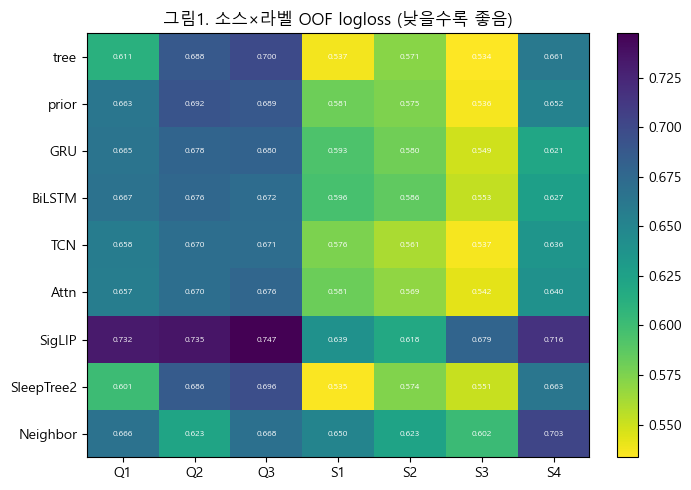

In [16]:
ll=np.zeros((len(SRC),7))
for si,s in enumerate(SRC):
    for j in range(7): ll[si,j]=log_loss(y[:,j],C(src_oof[s][:,j]),labels=[0,1])
fig,ax=plt.subplots(figsize=(7,5))
im=ax.imshow(ll,aspect="auto",cmap="viridis_r")
ax.set_xticks(range(7)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(len(SRC))); ax.set_yticklabels(SRC)
for a in range(len(SRC)):
    for b in range(7): ax.text(b,a,f"{ll[a,b]:.3f}",ha="center",va="center",fontsize=6,color="w")
ax.set_title("그림1. 소스×라벨 OOF logloss (낮을수록 좋음)"); plt.colorbar(im,fraction=.04)
plt.tight_layout(); plt.show()

### 그림2. 타겟별 블렌드 가중치
greedy coordinate-descent가 고른 소스 가중치. prior 앵커 위에서 라벨마다 다른 소스를 가져다 쓰는 것을 볼 수 있다.
(Q1/Q2는 daystate 라우팅 포함)

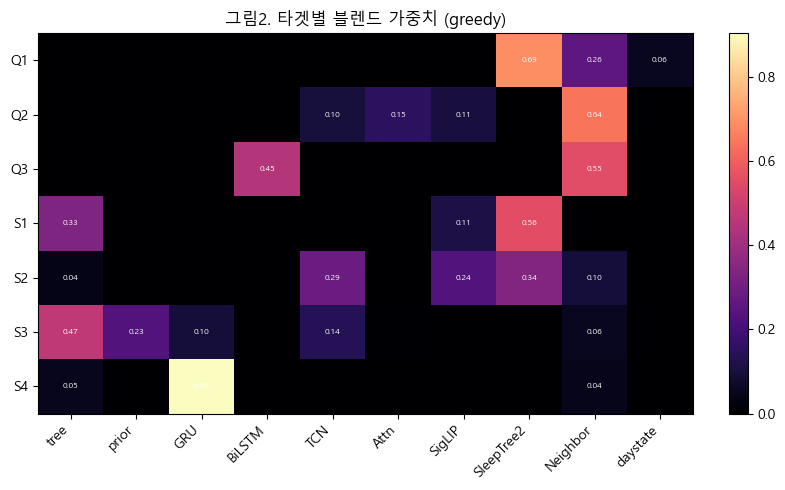

In [17]:
cols=SRC+["daystate"]; W=np.zeros((7,len(cols)))
for j in range(7):
    ol=oof_list9+([ds_o] if j in (0,1) else [])
    w=greedy_weights_for_label(ol,rand_folds,j)
    for i in range(len(SRC)): W[j,i]=w[i]
    if j in (0,1): W[j,-1]=w[-1]
fig,ax=plt.subplots(figsize=(8,5))
im=ax.imshow(W,aspect="auto",cmap="magma")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=45,ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(LABELS)
for a in range(7):
    for b in range(len(cols)):
        if W[a,b]>0.01: ax.text(b,a,f"{W[a,b]:.2f}",ha="center",va="center",fontsize=6,color="w")
ax.set_title("그림2. 타겟별 블렌드 가중치 (greedy)"); plt.colorbar(im,fraction=.04)
plt.tight_layout(); plt.show()

### 그림3. ★ forward-CV 재가중 (S1/S4) — 동기(그림A)의 검증
같은 소스 집합인데 **무작위 폴드**로 고른 가중치와 **forward 폴드**(앞→뒤)로 고른 가중치가 다르다.
앞의 시간이동(그림A)에 맞춰 가중치를 옮긴 것이 이 솔루션의 **가장 큰 LB 개선 레버**.

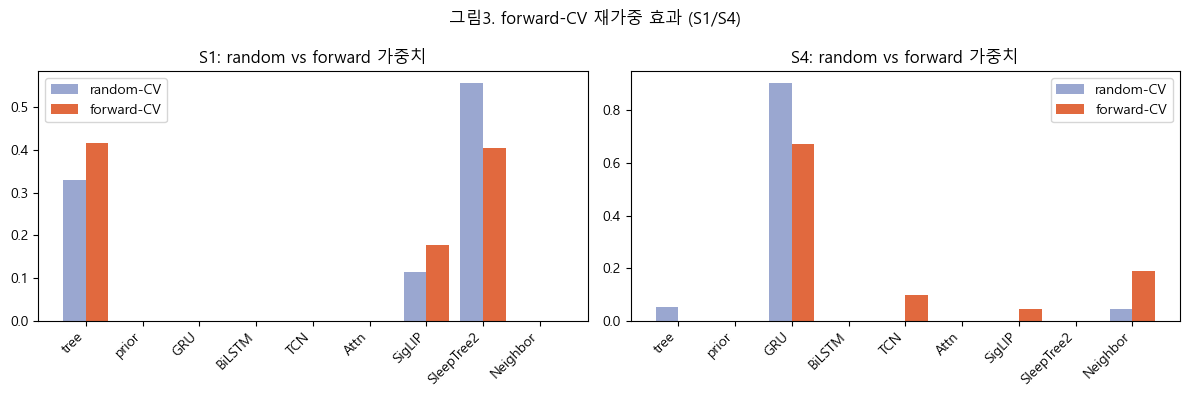

In [18]:
fig,axs=plt.subplots(1,2,figsize=(12,4))
for ax,j,nm in zip(axs,[3,6],["S1","S4"]):
    wr=greedy_weights_for_label(oof_list9,rand_folds,j)
    wf=greedy_weights_for_label(oof_list9,forward_folds,j)
    x=np.arange(len(SRC))
    ax.bar(x-.2,wr,.4,label="random-CV",color="#9aa7d0")
    ax.bar(x+.2,wf,.4,label="forward-CV",color="#e1693e")
    ax.set_xticks(x); ax.set_xticklabels(SRC,rotation=45,ha="right")
    ax.set_title(f"{nm}: random vs forward 가중치"); ax.legend()
fig.suptitle("그림3. forward-CV 재가중 효과 (S1/S4)")
plt.tight_layout(); plt.show()

### 그림4. 소스 예측 상관
소스들이 서로 **비상관**일수록 블렌드 이득이 크다. 트리/시퀀스DL/비전(SigLIP)/수면재구성/이웃이
서로 다른 관점이라 상관이 낮게 유지되는 것을 확인.

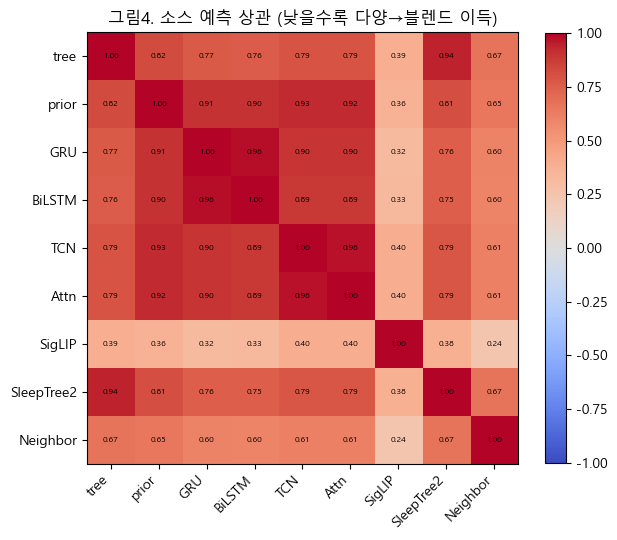

In [19]:
M=np.column_stack([src_oof[s].reshape(-1) for s in SRC])
corr=np.corrcoef(M.T)
fig,ax=plt.subplots(figsize=(6.5,5.5))
im=ax.imshow(corr,cmap="coolwarm",vmin=-1,vmax=1)
ax.set_xticks(range(len(SRC))); ax.set_xticklabels(SRC,rotation=45,ha="right")
ax.set_yticks(range(len(SRC))); ax.set_yticklabels(SRC)
for a in range(len(SRC)):
    for b in range(len(SRC)): ax.text(b,a,f"{corr[a,b]:.2f}",ha="center",va="center",fontsize=6)
ax.set_title("그림4. 소스 예측 상관 (낮을수록 다양→블렌드 이득)"); plt.colorbar(im,fraction=.04)
plt.tight_layout(); plt.show()